In [110]:
# =============================================================================
# CELL 1 — SETUP
# =============================================================================

import glob
import re
import numpy as np
import xarray as xr
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pickle
import pandas as pd
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from scipy.spatial import cKDTree

matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif']  = ['cmr10', 'Computer Modern Roman', 'DejaVu Serif']
matplotlib.rcParams['axes.formatter.use_mathtext'] = True

# ── paths ─────────────────────────────────────────────────────────────────────
DATA_PATH     = Path("/mnt/storage7/clark/NEMO/Simulations/ARC60/Model_Runs/ARC60-ECP004")
EKE_PATH      = Path("/mnt/storage7/clark/NEMO/Analysis/ARC60/EKE_percell/NcFiles/IndividualDays")
PROCESSED_DIR = Path("../processedData")
FIGURES_DIR   = Path("../figures")
PROCESSED_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

# ── year range ────────────────────────────────────────────────────────────────
YEAR_START = 1994
YEAR_END   = 2001

# ── target depths and integration boundaries ──────────────────────────────────
TARGET_DEPTHS = [0, 50, 100, 200]
DEPTH_BOUNDARIES = {
    50:  (0,   50),
    100: (50,  100),
    200: (100, 200),
}

# ── season definitions ────────────────────────────────────────────────────────
SEASONS = {
    'JFM': [1, 2, 3],
    'AMJ': [4, 5, 6],
    'JAS': [7, 8, 9],
    'OND': [10, 11, 12],
}

# ── bounding box ──────────────────────────────────────────────────────────────
CROP_LON_MIN, CROP_LON_MAX = -180, -110
CROP_LAT_MIN, CROP_LAT_MAX =   65,   85

# ── file discovery ────────────────────────────────────────────────────────────
_DATE_RE_UV = re.compile(r'_y(\d{4})m(\d{2})d(\d{2})_grid[UV]')
_DATE_RE_T  = re.compile(r'_y(\d{4})m(\d{2})d(\d{2})_gridT')
_DATE_RE_EKE = re.compile(r'EKE_y(\d{4})m(\d{2})d(\d{2})')

def _parse_date_re(filepath, regex):
    m = regex.search(Path(filepath).name)
    if m:
        return int(m.group(1)), int(m.group(2)), int(m.group(3))
    return None

def _build_file_index(files, regex, y0, y1):
    index = {}
    for f in files:
        parsed = _parse_date_re(f, regex)
        if parsed:
            y, mo, d = parsed
            if y0 <= y <= y1:
                index[datetime(y, mo, d)] = f
    return dict(sorted(index.items()))

all_u   = glob.glob(str(DATA_PATH / "gridU"  / "*_gridU.nc"))
all_v   = glob.glob(str(DATA_PATH / "gridV"  / "*_gridV.nc"))
all_t   = glob.glob(str(DATA_PATH / "gridT"  / "*_gridT.nc"))
all_eke = glob.glob(str(EKE_PATH  / "*.nc"))

u_index   = _build_file_index(all_u,   _DATE_RE_UV,  YEAR_START, YEAR_END)
v_index   = _build_file_index(all_v,   _DATE_RE_UV,  YEAR_START, YEAR_END)
t_index   = _build_file_index(all_t,   _DATE_RE_T,   YEAR_START, YEAR_END)
eke_index = _build_file_index(all_eke, _DATE_RE_EKE, YEAR_START, YEAR_END)

common_dates     = sorted(set(u_index)   & set(v_index))
common_dates_t   = sorted(set(t_index))
common_dates_eke = sorted(set(eke_index) & set(t_index))  # EKE needs e3t from gridT

print(f"U/V pairs   : {len(common_dates)}")
print(f"gridT files : {len(common_dates_t)}")
print(f"EKE files   : {len(common_dates_eke)}")
print(f"  First: {common_dates[0].date()}   Last: {common_dates[-1].date()}")

# ── load nav_lat/lon and depth levels from first U and T files ────────────────
with xr.open_dataset(list(u_index.values())[0]) as ds:
    nav_lat        = ds['nav_lat'].load()
    nav_lon        = ds['nav_lon'].load()
    actual_depth_u = ds['depthu'].values         # (50,) for U/V

with xr.open_dataset(list(t_index.values())[0]) as ds:
    actual_depth_t = ds['deptht'].values         # (50,) for T/EKE

print(f"\nGrid shape   : {nav_lat.shape}")
print(f"U depth levels: {len(actual_depth_u)}")
print(f"T depth levels: {len(actual_depth_t)}")

# ── bounding box row/col slices ───────────────────────────────────────────────
_in_box = (
    (nav_lat.values >= CROP_LAT_MIN) & (nav_lat.values <= CROP_LAT_MAX) &
    (nav_lon.values >= CROP_LON_MIN) & (nav_lon.values <= CROP_LON_MAX) &
    (nav_lat.values > 0)
)
_box_rows = np.where(_in_box.any(axis=1))[0]
_box_cols = np.where(_in_box.any(axis=0))[0]
CROP_ROW_SLICE = slice(int(_box_rows[0]), int(_box_rows[-1]) + 1)
CROP_COL_SLICE = slice(int(_box_cols[0]), int(_box_cols[-1]) + 1)
CROP_ROW_MIN   = int(_box_rows[0])
CROP_COL_MIN   = int(_box_cols[0])
print(f"\nBounding box crop:")
print(f"  rows {CROP_ROW_MIN} → {_box_rows[-1]}  ({len(_box_rows)} rows)")
print(f"  cols {CROP_COL_MIN} → {_box_cols[-1]}  ({len(_box_cols)} cols)")

# ── Canadian Basin mask (cropped) ─────────────────────────────────────────────
CB_MASK_FILE = Path('/mnt/storage6/clark/NEMO_meshes/ARC60/ARC60_CanadianBasinMask.nc')
with xr.open_dataset(CB_MASK_FILE) as ds:
    _cb_full = ds['tmask'].values
CB_MASK = _cb_full[CROP_ROW_SLICE, CROP_COL_SLICE] > 0.5
print(f"\nCB mask shape (cropped): {CB_MASK.shape}")
print(f"CB mask active points  : {CB_MASK.sum()}")

# ── horizontal cell areas from mesh file ──────────────────────────────────────
MESH_HGR = Path('/mnt/storage6/clark/NEMO_meshes/ARC60/ARC60_mesh_hgr.nc')
with xr.open_dataset(MESH_HGR) as ds:
    e1t = ds['e1t'].values.squeeze()   # (y, x) after squeezing t dimension
    e2t = ds['e2t'].values.squeeze()   # (y, x)

CELL_AREA = (e1t * e2t)[CROP_ROW_SLICE, CROP_COL_SLICE].astype(np.float32)
print(f"Cell area shape (cropped): {CELL_AREA.shape}")
print(f"Cell area range: {CELL_AREA.min():.0f} – {CELL_AREA.max():.0f} m²")

# ── T-grid nav_lat/lon (for SSH and geostrophic computations) ─────────────────
with xr.open_dataset(list(t_index.values())[0]) as ds:
    nav_lat_t = ds['nav_lat_grid_T'].load()   # (y, x)
    nav_lon_t = ds['nav_lon_grid_T'].load()   # (y, x)

nav_lat_t_crop = nav_lat_t.values[CROP_ROW_SLICE, CROP_COL_SLICE]  # (n_rows, n_cols)
nav_lon_t_crop = nav_lon_t.values[CROP_ROW_SLICE, CROP_COL_SLICE]

# ── Coriolis parameter on cropped T-grid ──────────────────────────────────────
OMEGA    = 7.2921e-5   # rad/s
G        = 9.81        # m/s²
F_CORIOLIS = (2 * OMEGA * np.sin(np.deg2rad(nav_lat_t_crop))).astype(np.float32)
# (no equator problem — domain is 65–85°N, |f| > 1.26e-4)
print(f"\nCoriolis range: {F_CORIOLIS.min():.4e} – {F_CORIOLIS.max():.4e} rad/s")

# ── e1t / e2t already loaded for CELL_AREA, extract crops separately ──────────
# e1t = zonal grid spacing at T points (m)
# e2t = meridional grid spacing at T points (m)
# already loaded above as (y,x) arrays — just crop them for SSH gradient use
E1T_CROP = e1t[CROP_ROW_SLICE, CROP_COL_SLICE].astype(np.float32)  # dx at T (m)
E2T_CROP = e2t[CROP_ROW_SLICE, CROP_COL_SLICE].astype(np.float32)  # dy at T (m)
print(f"E1T crop range: {E1T_CROP.min():.0f} – {E1T_CROP.max():.0f} m")
print(f"E2T crop range: {E2T_CROP.min():.0f} – {E2T_CROP.max():.0f} m")

# ── update _FIELD_META with new fields ────────────────────────────────────────
# (add these to the _FIELD_META dict in Cell 3)
# 'ssh_std'        : {'label': 'SSH Standard Deviation',      'unit': 'SSH std (m)'}
# 'model_geo_speed': {'label': 'Model Geostrophic Speed',     'unit': 'Speed (m/s)'}

# ── depth indices for U grid ──────────────────────────────────────────────────
print("\nU-grid single-level depth mapping:")
single_depth_idx_u = {}
for target in TARGET_DEPTHS:
    idx = int(np.argmin(np.abs(actual_depth_u - target)))
    single_depth_idx_u[target] = idx
    print(f"  Target {target:>4} m  →  level {idx:2d}  (actual: {actual_depth_u[idx]:.2f} m)")

integrated_depth_idx_u = {}
print("\nU-grid integrated depth mapping:")
for target, (lower, upper) in DEPTH_BOUNDARIES.items():
    mask = (actual_depth_u >= lower) & (actual_depth_u <= upper) if lower == 0 \
           else (actual_depth_u > lower) & (actual_depth_u <= upper)
    idx = np.where(mask)[0]
    integrated_depth_idx_u[target] = idx
    print(f"  depth={target:>3}m ({lower}–{upper} m)  →  "
          f"{len(idx)} levels  "
          f"[{actual_depth_u[idx[0]]:.1f} – {actual_depth_u[idx[-1]]:.1f} m]")

# ── depth indices for T grid (EKE) ────────────────────────────────────────────
print("\nT-grid single-level depth mapping:")
single_depth_idx_t = {}
for target in TARGET_DEPTHS:
    idx = int(np.argmin(np.abs(actual_depth_t - target)))
    single_depth_idx_t[target] = idx
    print(f"  Target {target:>4} m  →  level {idx:2d}  (actual: {actual_depth_t[idx]:.2f} m)")

integrated_depth_idx_t = {}
print("\nT-grid integrated depth mapping:")
for target, (lower, upper) in DEPTH_BOUNDARIES.items():
    mask = (actual_depth_t >= lower) & (actual_depth_t <= upper) if lower == 0 \
           else (actual_depth_t > lower) & (actual_depth_t <= upper)
    idx = np.where(mask)[0]
    integrated_depth_idx_t[target] = idx
    print(f"  depth={target:>3}m ({lower}–{upper} m)  →  "
          f"{len(idx)} levels  "
          f"[{actual_depth_t[idx[0]]:.1f} – {actual_depth_t[idx[-1]]:.1f} m]")

# ── satellite data path and year range ───────────────────────────────────────
SAT_PATH       = Path("/mnt/storage6/myers/DATA/Copernicus-SeaLevel/"
                      "SEALEVEL_GLO_PHY_L4_MY_008_047/"
                      "cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_202411")
SAT_YEAR_START = 1994
SAT_YEAR_END   = 1999

# ── month definitions (for monthly SLA std) ───────────────────────────────────
MONTHS = {
    'Jan': [1],  'Feb': [2],  'Mar': [3],  'Apr': [4],
    'May': [5],  'Jun': [6],  'Jul': [7],  'Aug': [8],
    'Sep': [9],  'Oct': [10], 'Nov': [11], 'Dec': [12],
}

# ── satellite file discovery ──────────────────────────────────────────────────
# matches first date in filename, ignores second reprocessing date
_DATE_RE_SAT = re.compile(r'_l4_(\d{4})(\d{2})(\d{2})_\d{8}\.nc$')

_all_sat = glob.glob(str(SAT_PATH / "**" / "*.nc"), recursive=True)
sat_index = {}
for _f in _all_sat:
    _m = _DATE_RE_SAT.search(Path(_f).name)
    if _m:
        _y, _mo, _d = int(_m.group(1)), int(_m.group(2)), int(_m.group(3))
        if SAT_YEAR_START <= _y <= SAT_YEAR_END:
            sat_index[datetime(_y, _mo, _d)] = _f
sat_index = dict(sorted(sat_index.items()))
sat_dates = sorted(sat_index.keys())
print(f"\nSatellite files : {len(sat_dates)}")
if sat_dates:
    print(f"  First: {sat_dates[0].date()}   Last: {sat_dates[-1].date()}")

# ── load lat/lon from first file and compute bounding box slices ──────────────
with xr.open_dataset(list(sat_index.values())[0]) as _ds:
    _sat_lat_full = _ds['latitude'].values    # (1440,) 1D regular
    _sat_lon_full = _ds['longitude'].values   # (2880,) 1D regular

_lat_mask = (_sat_lat_full >= CROP_LAT_MIN) & (_sat_lat_full <= CROP_LAT_MAX)
_lon_mask = (_sat_lon_full >= CROP_LON_MIN) & (_sat_lon_full <= CROP_LON_MAX)

SAT_LAT_SLICE = slice(int(np.where(_lat_mask)[0][0]),  int(np.where(_lat_mask)[0][-1])  + 1)
SAT_LON_SLICE = slice(int(np.where(_lon_mask)[0][0]),  int(np.where(_lon_mask)[0][-1])  + 1)

sat_lat = _sat_lat_full[SAT_LAT_SLICE]   # 1D (n_lat,)
sat_lon = _sat_lon_full[SAT_LON_SLICE]   # 1D (n_lon,)

print(f"Satellite crop  : lat {sat_lat[0]:.4f} → {sat_lat[-1]:.4f}  ({len(sat_lat)} pts)")
print(f"                  lon {sat_lon[0]:.4f} → {sat_lon[-1]:.4f}  ({len(sat_lon)} pts)")
print(f"Satellite grid shape: ({len(sat_lat)}, {len(sat_lon)})")

# ── CB mask bounding box (for scale-of-variability analysis) ─────────────────
# Extract the rectangular bounding box of the CB mask on the full grid
_cb_rows = np.where(_cb_full.any(axis=1))[0]
_cb_cols = np.where(_cb_full.any(axis=0))[0]
CB_ROW_SLICE = slice(int(_cb_rows[0]), int(_cb_rows[-1]) + 1)
CB_COL_SLICE = slice(int(_cb_cols[0]), int(_cb_cols[-1]) + 1)
CB_ROW_MIN   = int(_cb_rows[0])
CB_COL_MIN   = int(_cb_cols[0])

# CB-region nav_lat/lon and cell sizes (for the box filter)
CB_NAV_LAT  = nav_lat.values[CB_ROW_SLICE, CB_COL_SLICE]   # (n_cb_rows, n_cb_cols)
CB_NAV_LON  = nav_lon.values[CB_ROW_SLICE, CB_COL_SLICE]
CB_E1T      = e1t[CB_ROW_SLICE, CB_COL_SLICE].astype(np.float32)   # zonal spacing (m)
CB_E2T      = e2t[CB_ROW_SLICE, CB_COL_SLICE].astype(np.float32)   # meridional spacing (m)
CB_MASK_SOV = _cb_full[CB_ROW_SLICE, CB_COL_SLICE] > 0.5           # (n_cb_rows, n_cb_cols)

print(f"\nCB bounding box for scale-of-variability:")
print(f"  rows {CB_ROW_MIN} → {_cb_rows[-1]}  ({CB_MASK_SOV.shape[0]} rows)")
print(f"  cols {CB_COL_MIN} → {_cb_cols[-1]}  ({CB_MASK_SOV.shape[1]} cols)")
print(f"  CB mask active points in box: {CB_MASK_SOV.sum()}")
print(f"  Mean e1t (zonal spacing)    : {CB_E1T[CB_MASK_SOV].mean()/1000:.2f} km")
print(f"  Mean e2t (meridional spacing): {CB_E2T[CB_MASK_SOV].mean()/1000:.2f} km")

# ── scale definitions (km) matching Cole paper ────────────────────────────────
SOV_SCALES_KM = [7, 30, 60, 120, 240, 480]   # low-pass cutoff scales in km

# ── icemod file index ─────────────────────────────────────────────────────────
_DATE_RE_ICE = re.compile(r'_y(\d{4})m(\d{2})d(\d{2})_icemod')
all_ice  = glob.glob(str(DATA_PATH / "icemod" / "*_icemod.nc"))
ice_index = _build_file_index(all_ice, _DATE_RE_ICE, YEAR_START, YEAR_END)
print(f"Icemod files: {len(ice_index)}")


# ── 1. load mooring data ──────────────────────────────────────────────────────
VAPPEN_FILE = Path('/mnt/storage6/myers/DATA/EKE/vonAppen-etal_2022.tab')

df = pd.read_csv(
    VAPPEN_FILE,
    sep      = '\t',
    skiprows = 300,       # skip all metadata up to and including the */ line
    header   = 0,         # row 300 is the column header
    na_values = [''],
)

# clean column names — strip whitespace
df.columns = df.columns.str.strip()

print(f"Loaded {len(df)} mooring records")
print(f"Columns: {list(df.columns)}")
print(f"\nLat range : {df['Latitude'].min():.2f} → {df['Latitude'].max():.2f}")
print(f"Lon range : {df['Longitude'].min():.2f} → {df['Longitude'].max():.2f}")
print(f"Depth top : {df['Depth top [m]'].min():.0f} → {df['Depth top [m]'].max():.0f} m")
print(f"\nEKE mean range: {df['EKE mean [m**2/s**2]'].min():.2e} → {df['EKE mean [m**2/s**2]'].max():.2e} m²/s²")
print(f"Valid EKE mean : {df['EKE mean [m**2/s**2]'].notna().sum()} / {len(df)}")

# ── bathymetry mask (ocean depth > 100 m) ────────────────────────────────────
MESH_ZGR = Path("/mnt/storage6/clark/NEMO_meshes/ARC60/ARC60_mesh_zgr.nc")

with xr.open_dataset(MESH_ZGR) as ds:
    hdept_crop = ds['hdept'].isel(
        t=0,
        y=CROP_ROW_SLICE,
        x=CROP_COL_SLICE,
    ).values.astype(np.float32)

BATHY_MASK_100 = hdept_crop > 100.0

print(f"Bathymetry mask (depth > 100 m):")
print(f"  Deep pixels  : {BATHY_MASK_100.sum()}  ({100*BATHY_MASK_100.mean():.1f}%)")
print(f"  Depth range  : {hdept_crop[hdept_crop > 0].min():.1f} -- {hdept_crop.max():.1f} m")

# ── save bathymetry mask once ─────────────────────────────────────────────────
BATHY_MASK_PATH = PROCESSED_DIR / 'bathy_mask_100m.npz'
if not BATHY_MASK_PATH.exists():
    np.savez_compressed(BATHY_MASK_PATH, bathy_mask=BATHY_MASK_100.astype(np.uint8))
    print(f"Saved bathymetry mask → {BATHY_MASK_PATH.name}")

print("Building satellite bathymetry mask...")

# ── use FULL model grid for the KD-tree, not just the bounding box ────────────
with xr.open_dataset(MESH_ZGR) as ds:
    hdept_full = ds['hdept'].isel(t=0).values   # (7025, 7500)

bathy_full_flat = (hdept_full > 100.0).ravel()   # full grid mask

first_u_file = list(u_index.values())[0]
with xr.open_dataset(first_u_file) as ds:
    nav_lat_full = ds['nav_lat'].values.ravel()
    nav_lon_full = ds['nav_lon'].values.ravel()

# build KD-tree on full model grid
_tree = cKDTree(np.column_stack([nav_lat_full, nav_lon_full]))

# satellite grid
_sat_lon2d, _sat_lat2d = np.meshgrid(sat_lon, sat_lat)
sat_points = np.column_stack([_sat_lat2d.ravel(), _sat_lon2d.ravel()])

# query — idx now safely indexes into bathy_full_flat
_, idx = _tree.query(sat_points, workers=-1)
BATHY_MASK_100_SAT = bathy_full_flat[idx].reshape(_sat_lat2d.shape)

print(f"Satellite bathy mask shape : {BATHY_MASK_100_SAT.shape}")
print(f"Deep pixels : {BATHY_MASK_100_SAT.sum()}  ({100*BATHY_MASK_100_SAT.mean():.1f}%)")

U/V pairs   : 2916
gridT files : 2916
EKE files   : 2186
  First: 1994-01-01   Last: 2001-12-31

Grid shape   : (7025, 7500)
U depth levels: 50
T depth levels: 50

Bounding box crop:
  rows 4115 → 6979  (2865 rows)
  cols 531 → 4019  (3489 cols)

CB mask shape (cropped): (2865, 3489)
CB mask active points  : 1536992
Cell area shape (cropped): (2865, 3489)
Cell area range: 107177 – 1047762 m²

Coriolis range: -2.5453e-06 – 1.4580e-04 rad/s
E1T crop range: 434 – 984 m
E2T crop range: 247 – 1065 m

U-grid single-level depth mapping:
  Target    0 m  →  level  0  (actual: 0.49 m)
  Target   50 m  →  level 17  (actual: 47.37 m)
  Target  100 m  →  level 21  (actual: 92.33 m)
  Target  200 m  →  level 25  (actual: 186.13 m)

U-grid integrated depth mapping:
  depth= 50m (0–50 m)  →  18 levels  [0.5 – 47.4 m]
  depth=100m (50–100 m)  →  4 levels  [55.8 – 92.3 m]
  depth=200m (100–200 m)  →  4 levels  [109.7 – 186.1 m]

T-grid single-level depth mapping:
  Target    0 m  →  level  0  (actual: 

In [101]:
# =============================================================================
# CELL 2 — PREPROCESSING + FIELD FUNCTIONS (speed, fwt, eke) + VERTICAL PROFILES
# =============================================================================

GRID_FILE     = PROCESSED_DIR / "grid.npz"
TRI_CACHE_DIR = PROCESSED_DIR / "cache"
TRI_CACHE_DIR.mkdir(exist_ok=True)
_TRI_CACHE = {}
_GRID_LAT  = None
_GRID_LON  = None
PROFILE_DEPTH_SLICE_U = slice(0, 26)   # levels 0–25 inclusive
PROFILE_DEPTH_SLICE_T = slice(0, 26)

# ── grid helpers ──────────────────────────────────────────────────────────────
def _save_grid_once():
    if GRID_FILE.exists():
        return
    print(f"Saving grid file → {GRID_FILE}")
    np.savez_compressed(
        GRID_FILE,
        nav_lat = nav_lat.values[CROP_ROW_SLICE, CROP_COL_SLICE],
        nav_lon = nav_lon.values[CROP_ROW_SLICE, CROP_COL_SLICE],
        row_min = np.array(CROP_ROW_MIN),
        col_min = np.array(CROP_COL_MIN),
    )
    print("Grid file saved.")

def _load_grid():
    if not GRID_FILE.exists():
        raise FileNotFoundError(f"Grid file not found: {GRID_FILE}\nRun _save_grid_once() first.")
    g = np.load(GRID_FILE)
    return g['nav_lat'], g['nav_lon']

def _ensure_grid():
    global _GRID_LAT, _GRID_LON
    if _GRID_LAT is None:
        _GRID_LAT, _GRID_LON = _load_grid()

def _load_npz(path):
    f = np.load(path)
    data = f['field']
    meta = {
        'period'     : str(f['period']),
        'depth_info' : str(f['depth_info']),
        'integrated' : str(f['integrated']) == 'True',
        'field_name' : str(f['field_name']),
        'depth_m'    : str(f['depth_m']),
        'row_min'    : int(f['row_min']),
        'col_min'    : int(f['col_min']),
    }
    return data, meta

def _get_triangulation(lat, lon, step):
    key = (step, lat.shape)
    if key in _TRI_CACHE:
        return _TRI_CACHE[key]
    cache_file = TRI_CACHE_DIR / f"triangulation_step{step}_{lat.shape[0]}x{lat.shape[1]}.pkl"
    if cache_file.exists():
        print(f"Loading cached triangulation from {cache_file.name} ...")
        with open(cache_file, 'rb') as f:
            triang, mask_s = pickle.load(f)
        _TRI_CACHE[key] = (triang, mask_s)
        return triang, mask_s
    print("Building triangulation (first time only) ...")
    fill_mask = (lat <= 0)
    lat_s  = lat[::step, ::step]
    lon_s  = lon[::step, ::step]
    mask_s = fill_mask[::step, ::step]
    triang = mtri.Triangulation(lon_s[~mask_s], lat_s[~mask_s])
    with open(cache_file, 'wb') as f:
        pickle.dump((triang, mask_s), f)
    print(f"Triangulation cached to {cache_file.name}")
    _TRI_CACHE[key] = (triang, mask_s)
    return triang, mask_s

_CB_MASK_PLOT = None
def _ensure_mask():
    global _CB_MASK_PLOT
    if _CB_MASK_PLOT is None:
        with xr.open_dataset(CB_MASK_FILE) as ds:
            _CB_MASK_PLOT = ds['tmask'].values
    return _CB_MASK_PLOT

# ── shared helpers ────────────────────────────────────────────────────────────
def _parse_timeperiod(timePeriod):
    if isinstance(timePeriod, str) and timePeriod.startswith('y'):
        m = re.match(r'y(\d{4})m(\d{2})d(\d{2})', timePeriod)
        if not m:
            raise ValueError(f"Date string must be 'yYYYYmMMdDD', got {timePeriod!r}")
        date = datetime(int(m.group(1)), int(m.group(2)), int(m.group(3)))
        return timePeriod, [date]
    elif isinstance(timePeriod, int):
        selected = [d for d in common_dates if d.year == timePeriod]
        if not selected:
            raise ValueError(f"No dates found for year {timePeriod}")
        return str(timePeriod), selected
    elif isinstance(timePeriod, str) and timePeriod in SEASONS:
        months   = SEASONS[timePeriod]
        selected = [d for d in common_dates if d.month in months]
        if not selected:
            raise ValueError(f"No dates found for season {timePeriod}")
        return timePeriod, selected
    else:
        raise ValueError(f"timePeriod must be 'yYYYYmMMdDD', int year, or one of {list(SEASONS.keys())}.")

def _save_field(out_path, field, label, depth_info, depth_m, integrated, n_days, field_name):
    np.savez_compressed(
        out_path,
        field      = field,
        period     = np.array(label),
        depth_info = np.array(depth_info),
        depth_m    = np.array(str(depth_m)),
        integrated = np.array(str(integrated)),
        n_days     = np.array(str(n_days)),
        field_name = np.array(field_name),
        row_min    = np.array(CROP_ROW_MIN),
        col_min    = np.array(CROP_COL_MIN),
    )

def _save_timeseries(ts_path, ts_values, ts_dates, label, depth_info, depth_m, integrated, field_name):
    np.savez_compressed(
        ts_path,
        values     = np.array(ts_values, dtype=np.float32),
        dates      = np.array(ts_dates),
        depth_info = np.array(depth_info),
        depth_m    = np.array(str(depth_m)),
        integrated = np.array(str(integrated)),
        period     = np.array(label),
        field_name = np.array(field_name),
    )

def _save_vprofile(out_path, profile_values, depths, label, field_name, n_days):
    """Save a vertical profile: (n_depths,) array + depth axis."""
    np.savez_compressed(
        out_path,
        values     = np.array(profile_values, dtype=np.float32),
        depths     = np.array(depths, dtype=np.float32),
        period     = np.array(label),
        field_name = np.array(field_name),
        n_days     = np.array(str(n_days)),
    )

def _weighted_vertical_average(field_3d, e3_3d):
    e3_safe  = np.where(np.isfinite(e3_3d), e3_3d, 0.0)
    total_e3 = np.nansum(e3_safe, axis=0)
    result   = np.nansum(field_3d * e3_safe, axis=0) / np.where(total_e3 > 0, total_e3, np.nan)
    result[np.all(~np.isfinite(field_3d), axis=0)] = np.nan
    return result

def _compute_speed(u, v):
    u_t   = 0.5 * (u + np.roll(u, 1, axis=-1))
    v_t   = 0.5 * (v + np.roll(v, 1, axis=-2))
    speed = np.sqrt(u_t**2 + v_t**2).astype(np.float32)
    speed[~np.isfinite(u) & ~np.isfinite(v)] = np.nan
    return speed

def _depth_info_str(depth, integrated):
    if depth == 0:
        return 'at the Surface'
    elif integrated:
        lo, hi = DEPTH_BOUNDARIES[depth]
        return f'integrated from {lo} to {hi} m'
    else:
        return f'at {depth} m Depth'

def _masked_weighted_mean(field_2d):
    """Area-weighted spatial mean over the Canadian Basin mask (2D field)."""
    weights = CELL_AREA[CB_MASK]
    values  = field_2d[CB_MASK]
    valid   = np.isfinite(values)
    if not valid.any():
        return np.nan
    return float(np.sum(values[valid] * weights[valid]) / np.sum(weights[valid]))

def _masked_weighted_mean_3d(field_3d):
    """
    Area-weighted spatial mean over CB mask at each depth level.
    field_3d : (n_depths, n_rows, n_cols)
    returns  : (n_depths,) array
    """
    weights = CELL_AREA[CB_MASK]   # (n_mask_pts,)
    n_depths = field_3d.shape[0]
    profile  = np.full(n_depths, np.nan, dtype=np.float64)
    for k in range(n_depths):
        vals  = field_3d[k][CB_MASK]
        valid = np.isfinite(vals)
        if valid.any():
            profile[k] = np.sum(vals[valid] * weights[valid]) / np.sum(weights[valid])
    return profile.astype(np.float32)

# =============================================================================
# SPEED
# =============================================================================

SPEED_DIR = PROCESSED_DIR / "speed"
SPEED_DIR.mkdir(exist_ok=True)

def SingleFilePreprocessing(date, depth, integrated=False):
    if depth not in TARGET_DEPTHS:
        raise ValueError(f"depth must be one of {TARGET_DEPTHS}, got {depth}")
    if integrated and depth == 0:
        raise ValueError("integrated=True is not valid for depth=0.")
    uf = u_index[date]
    vf = v_index[date]
    if not integrated:
        d_idx = single_depth_idx_u[depth]
        with xr.open_dataset(uf) as ds:
            u = ds['vozocrtx'].isel(time_counter=0, depthu=d_idx).values
        with xr.open_dataset(vf) as ds:
            v = ds['vomecrty'].isel(time_counter=0, depthv=d_idx).values
        u[np.abs(u) > 1e10] = np.nan
        v[np.abs(v) > 1e10] = np.nan
    else:
        idx       = integrated_depth_idx_u[depth]
        idx_slice = slice(int(idx.min()), int(idx.max()) + 1)
        with xr.open_dataset(uf) as ds:
            u_3d = ds['vozocrtx'].isel(time_counter=0, depthu=idx_slice).values
            e3u  = ds['e3u'].isel(time_counter=0,      depthu=idx_slice).values
        with xr.open_dataset(vf) as ds:
            v_3d = ds['vomecrty'].isel(time_counter=0, depthv=idx_slice).values
            e3v  = ds['e3v'].isel(time_counter=0,      depthv=idx_slice).values
        u_3d[np.abs(u_3d) > 1e10] = np.nan
        v_3d[np.abs(v_3d) > 1e10] = np.nan
        e3u[ np.abs(e3u)  > 1e10] = np.nan
        e3v[ np.abs(e3v)  > 1e10] = np.nan
        u = _weighted_vertical_average(u_3d, e3u)
        v = _weighted_vertical_average(v_3d, e3v)
    u = u[CROP_ROW_SLICE, CROP_COL_SLICE]
    v = v[CROP_ROW_SLICE, CROP_COL_SLICE]
    return u.astype(np.float32), v.astype(np.float32)


def _read_full_uv(date):
    uf = u_index[date]
    vf = v_index[date]
    with xr.open_dataset(uf) as ds:
        u_3d = ds['vozocrtx'].isel(
            time_counter=0,
            depthu=PROFILE_DEPTH_SLICE_U,
            y=CROP_ROW_SLICE,
            x=CROP_COL_SLICE,
        ).values
    with xr.open_dataset(vf) as ds:
        v_3d = ds['vomecrty'].isel(
            time_counter=0,
            depthv=PROFILE_DEPTH_SLICE_U,
            y=CROP_ROW_SLICE,
            x=CROP_COL_SLICE,
        ).values
    u_3d[np.abs(u_3d) > 1e10] = np.nan
    v_3d[np.abs(v_3d) > 1e10] = np.nan
    return u_3d.astype(np.float32), v_3d.astype(np.float32)


def _read_full_eke(date):
    ef = eke_index[date]
    with xr.open_dataset(ef) as ds:
        eke_3d = ds['EKE'].isel(
            z=PROFILE_DEPTH_SLICE_T,
            y=CROP_ROW_SLICE,
            x=CROP_COL_SLICE,
        ).values
    eke_3d[np.abs(eke_3d) > 1e10] = np.nan
    return eke_3d.astype(np.float32)


def speedField(timePeriod, depth, integrated=False, timeseries=False):
    if integrated and depth == 0:
        raise ValueError("integrated=True is not valid for depth=0")
    if timeseries and not isinstance(timePeriod, int):
        raise ValueError("timeseries=True is only valid for year calls (integer timePeriod)")

    label, selected_dates = _parse_timeperiod(timePeriod)
    suffix     = '_int' if integrated else ''
    out_path   = SPEED_DIR / f"speed_{label}_{depth}{suffix}.npz"
    ts_path    = SPEED_DIR / f"timeseries_speed_{label}_{depth}{suffix}.npz"
    depth_info = _depth_info_str(depth, integrated)

    if timeseries:
        if ts_path.exists():
            print(f"Already exists — skipping: {ts_path.name}")
            return ts_path
        _save_grid_once()
        print(f"Computing speed timeseries | Period: {label} | Depth: {depth}m | integrated: {integrated}")
        ts_values, ts_dates = [], []
        for date in tqdm(selected_dates, desc=f"speed ts {label}"):
            u, v = SingleFilePreprocessing(date, depth, integrated=integrated)
            speed = _compute_speed(u, v)
            ts_values.append(_masked_weighted_mean(speed))
            ts_dates.append(date.strftime('%Y-%m-%d'))
            del u, v, speed
        _save_timeseries(ts_path, ts_values, ts_dates, label, depth_info,
                         depth, integrated, 'speed')
        print(f"Saved → {ts_path.name}")
        return ts_path

    if out_path.exists():
        print(f"Already exists — skipping: {out_path.name}")
        return out_path
    _save_grid_once()
    print(f"Computing speed field | Period: {label} | Depth: {depth}m | integrated: {integrated}")
    u_sum = v_sum = n_valid_u = n_valid_v = None
    for date in tqdm(selected_dates, desc=f"speed {label}"):
        u, v = SingleFilePreprocessing(date, depth, integrated=integrated)
        u_fin, v_fin = np.isfinite(u), np.isfinite(v)
        if u_sum is None:
            u_sum     = np.where(u_fin, u, 0.0).astype(np.float64)
            v_sum     = np.where(v_fin, v, 0.0).astype(np.float64)
            n_valid_u = u_fin.astype(np.int32)
            n_valid_v = v_fin.astype(np.int32)
        else:
            u_sum     += np.where(u_fin, u, 0.0)
            v_sum     += np.where(v_fin, v, 0.0)
            n_valid_u += u_fin.astype(np.int32)
            n_valid_v += v_fin.astype(np.int32)
        del u, v
    u_mean = (u_sum / np.where(n_valid_u > 0, n_valid_u, 1)).astype(np.float32)
    v_mean = (v_sum / np.where(n_valid_v > 0, n_valid_v, 1)).astype(np.float32)
    u_mean[n_valid_u == 0] = np.nan
    v_mean[n_valid_v == 0] = np.nan
    speed = _compute_speed(u_mean, v_mean)
    _save_field(out_path, speed, label, depth_info, depth, integrated,
                len(selected_dates), 'speed')
    print(f"Saved → {out_path.name}")
    return out_path


# =============================================================================
# FRESHWATER THICKNESS
# =============================================================================

FWT_DIR = PROCESSED_DIR / "fwt"
FWT_DIR.mkdir(exist_ok=True)

def SingleFileFWT(date):
    tf = t_index[date]
    with xr.open_dataset(tf) as ds:
        fwt = ds['fwt348'].isel(time_counter=0).values
    fwt[np.abs(fwt) > 1e10] = np.nan
    fwt = fwt[CROP_ROW_SLICE, CROP_COL_SLICE]
    return fwt.astype(np.float32)


def fwtField(timePeriod, timeseries=False):
    if timeseries and not isinstance(timePeriod, int):
        raise ValueError("timeseries=True is only valid for year calls (integer timePeriod)")

    label, selected_dates = _parse_timeperiod(timePeriod)
    selected_dates = [d for d in selected_dates if d in t_index]
    if not selected_dates:
        raise ValueError(f"No gridT files found for {label}")

    out_path   = FWT_DIR / f"fwt_{label}.npz"
    ts_path    = FWT_DIR / f"timeseries_fwt_{label}.npz"
    depth_info = 'full column'

    if timeseries:
        if ts_path.exists():
            print(f"Already exists — skipping: {ts_path.name}")
            return ts_path
        _save_grid_once()
        print(f"Computing FWT timeseries | Period: {label}")
        ts_values, ts_dates = [], []
        for date in tqdm(selected_dates, desc=f"fwt ts {label}"):
            fwt = SingleFileFWT(date)
            ts_values.append(_masked_weighted_mean(fwt))
            ts_dates.append(date.strftime('%Y-%m-%d'))
            del fwt
        _save_timeseries(ts_path, ts_values, ts_dates, label, depth_info,
                         'none', False, 'fwt348')
        print(f"Saved → {ts_path.name}")
        return ts_path

    if out_path.exists():
        print(f"Already exists — skipping: {out_path.name}")
        return out_path
    _save_grid_once()
    print(f"Computing FWT field | Period: {label}")
    fwt_sum = None
    n_valid = None
    for date in tqdm(selected_dates, desc=f"fwt {label}"):
        fwt = SingleFileFWT(date)
        fin = np.isfinite(fwt)
        if fwt_sum is None:
            fwt_sum = np.where(fin, fwt, 0.0).astype(np.float64)
            n_valid = fin.astype(np.int32)
        else:
            fwt_sum += np.where(fin, fwt, 0.0)
            n_valid += fin.astype(np.int32)
        del fwt
    fwt_mean = (fwt_sum / np.where(n_valid > 0, n_valid, 1)).astype(np.float32)
    fwt_mean[n_valid == 0] = np.nan
    _save_field(out_path, fwt_mean, label, depth_info, 'none', False,
                len(selected_dates), 'fwt348')
    print(f"Saved → {out_path.name}")
    return out_path


# =============================================================================
# EDDY KINETIC ENERGY
# =============================================================================

EKE_DIR = PROCESSED_DIR / "eke"
EKE_DIR.mkdir(exist_ok=True)

def SingleFileEKE(date, depth, integrated=False):
    ef = eke_index[date]
    tf = t_index[date]
    if not integrated:
        d_idx = single_depth_idx_t[depth]
        with xr.open_dataset(ef) as ds:
            eke = ds['EKE'].isel(z=d_idx).values
        eke[np.abs(eke) > 1e10] = np.nan
    else:
        idx       = integrated_depth_idx_t[depth]
        idx_slice = slice(int(idx.min()), int(idx.max()) + 1)
        with xr.open_dataset(ef) as ds:
            eke_3d = ds['EKE'].isel(z=idx_slice).values
        with xr.open_dataset(tf) as ds:
            e3t = ds['e3t'].isel(time_counter=0, deptht=idx_slice).values
        eke_3d[np.abs(eke_3d) > 1e10] = np.nan
        e3t[   np.abs(e3t)    > 1e10] = np.nan
        eke = _weighted_vertical_average(eke_3d, e3t)
    eke = eke[CROP_ROW_SLICE, CROP_COL_SLICE]
    return eke.astype(np.float32)


def ekeField(timePeriod, depth, integrated=False, timeseries=False):
    if integrated and depth == 0:
        raise ValueError("integrated=True is not valid for depth=0")
    if timeseries and not isinstance(timePeriod, int):
        raise ValueError("timeseries=True is only valid for year calls (integer timePeriod)")

    label, selected_dates = _parse_timeperiod(timePeriod)
    selected_dates = [d for d in selected_dates if d in eke_index and d in t_index]
    if not selected_dates:
        raise ValueError(f"No EKE/gridT files found for {label}")

    suffix     = '_int' if integrated else ''
    out_path   = EKE_DIR / f"eke_{label}_{depth}{suffix}.npz"
    ts_path    = EKE_DIR / f"timeseries_eke_{label}_{depth}{suffix}.npz"
    depth_info = _depth_info_str(depth, integrated)

    if timeseries:
        if ts_path.exists():
            print(f"Already exists — skipping: {ts_path.name}")
            return ts_path
        _save_grid_once()
        print(f"Computing EKE timeseries | Period: {label} | Depth: {depth}m | integrated: {integrated}")
        ts_values, ts_dates = [], []
        for date in tqdm(selected_dates, desc=f"eke ts {label}"):
            eke = SingleFileEKE(date, depth, integrated=integrated)
            ts_values.append(_masked_weighted_mean(eke))
            ts_dates.append(date.strftime('%Y-%m-%d'))
            del eke
        _save_timeseries(ts_path, ts_values, ts_dates, label, depth_info,
                         depth, integrated, 'EKE')
        print(f"Saved → {ts_path.name}")
        return ts_path

    if out_path.exists():
        print(f"Already exists — skipping: {out_path.name}")
        return out_path
    _save_grid_once()
    print(f"Computing EKE field | Period: {label} | Depth: {depth}m | integrated: {integrated}")
    eke_sum = None
    n_valid = None
    for date in tqdm(selected_dates, desc=f"eke {label}"):
        eke = SingleFileEKE(date, depth, integrated=integrated)
        fin = np.isfinite(eke)
        if eke_sum is None:
            eke_sum = np.where(fin, eke, 0.0).astype(np.float64)
            n_valid = fin.astype(np.int32)
        else:
            eke_sum += np.where(fin, eke, 0.0)
            n_valid += fin.astype(np.int32)
        del eke
    eke_mean = (eke_sum / np.where(n_valid > 0, n_valid, 1)).astype(np.float32)
    eke_mean[n_valid == 0] = np.nan
    _save_field(out_path, eke_mean, label, depth_info, depth, integrated,
                len(selected_dates), 'EKE')
    print(f"Saved → {out_path.name}")
    return out_path


# =============================================================================
# VERTICAL PROFILES
# =============================================================================

VERTICAL_PROFILES_DIR = PROCESSED_DIR / "vertical_profiles"
VERTICAL_PROFILES_DIR.mkdir(exist_ok=True)

def speedVerticalProfile(timePeriod):
    """
    Compute vertical profile of speed (horizontally averaged over CB mask)
    for the given time period.

    Strategy:
      1. Accumulate mean u_3d and v_3d over all dates (all 50 depth levels).
      2. C-grid interpolation once on the temporal mean fields.
      3. Compute speed at each depth level.
      4. Area-weighted horizontal mean over CB mask per depth → (50,) profile.

    Saves to: vprofile_speed_{label}.npz
    """
    label, selected_dates = _parse_timeperiod(timePeriod)
    out_path = VERTICAL_PROFILES_DIR / f"vprofile_speed_{label}.npz"

    if out_path.exists():
        print(f"Already exists — skipping: {out_path.name}")
        return out_path

    print(f"Computing speed vertical profile | Period: {label} ({len(selected_dates)} days)")

    u_sum = v_sum = n_valid_u = n_valid_v = None

    for date in tqdm(selected_dates, desc=f"vprofile speed {label}"):
        u_3d, v_3d = _read_full_uv(date)   # (50, n_rows, n_cols)

        u_fin = np.isfinite(u_3d)
        v_fin = np.isfinite(v_3d)

        if u_sum is None:
            u_sum     = np.where(u_fin, u_3d, 0.0).astype(np.float64)
            v_sum     = np.where(v_fin, v_3d, 0.0).astype(np.float64)
            n_valid_u = u_fin.astype(np.int32)
            n_valid_v = v_fin.astype(np.int32)
        else:
            u_sum     += np.where(u_fin, u_3d, 0.0)
            v_sum     += np.where(v_fin, v_3d, 0.0)
            n_valid_u += u_fin.astype(np.int32)
            n_valid_v += v_fin.astype(np.int32)
        del u_3d, v_3d

    # temporal mean (50, n_rows, n_cols)
    u_mean = (u_sum / np.where(n_valid_u > 0, n_valid_u, 1)).astype(np.float32)
    v_mean = (v_sum / np.where(n_valid_v > 0, n_valid_v, 1)).astype(np.float32)
    u_mean[n_valid_u == 0] = np.nan
    v_mean[n_valid_v == 0] = np.nan
    del u_sum, v_sum, n_valid_u, n_valid_v

    # C-grid interpolation at each depth level (vectorized over depth)
    u_t = 0.5 * (u_mean + np.roll(u_mean, 1, axis=-1))   # (50, n_rows, n_cols)
    v_t = 0.5 * (v_mean + np.roll(v_mean, 1, axis=-2))
    speed_3d = np.sqrt(u_t**2 + v_t**2).astype(np.float32)
    speed_3d[~np.isfinite(u_mean) & ~np.isfinite(v_mean)] = np.nan
    del u_mean, v_mean, u_t, v_t

    # horizontal area-weighted mean over CB mask at each depth
    profile = _masked_weighted_mean_3d(speed_3d)   # (50,)
    del speed_3d

    _save_vprofile(out_path, profile,
               actual_depth_u[PROFILE_DEPTH_SLICE_U],
               label, 'speed', len(selected_dates))
    print(f"Saved → {out_path.name}")
    return out_path


def ekeVerticalProfile(timePeriod):
    """
    Compute vertical profile of EKE (horizontally averaged over CB mask)
    for the given time period.

    Strategy:
      1. Accumulate mean EKE_3d over all dates (all 50 depth levels).
      2. Area-weighted horizontal mean over CB mask per depth → (50,) profile.

    Saves to: vprofile_eke_{label}.npz
    """
    label, selected_dates = _parse_timeperiod(timePeriod)
    selected_dates = [d for d in selected_dates if d in eke_index]
    if not selected_dates:
        raise ValueError(f"No EKE files found for {label}")

    out_path = VERTICAL_PROFILES_DIR / f"vprofile_eke_{label}.npz"

    if out_path.exists():
        print(f"Already exists — skipping: {out_path.name}")
        return out_path

    print(f"Computing EKE vertical profile | Period: {label} ({len(selected_dates)} days)")

    eke_sum = None
    n_valid = None

    for date in tqdm(selected_dates, desc=f"vprofile eke {label}"):
        eke_3d = _read_full_eke(date)   # (50, n_rows, n_cols)
        fin    = np.isfinite(eke_3d)

        if eke_sum is None:
            eke_sum = np.where(fin, eke_3d, 0.0).astype(np.float64)
            n_valid = fin.astype(np.int32)
        else:
            eke_sum += np.where(fin, eke_3d, 0.0)
            n_valid += fin.astype(np.int32)
        del eke_3d

    eke_mean = (eke_sum / np.where(n_valid > 0, n_valid, 1)).astype(np.float32)
    eke_mean[n_valid == 0] = np.nan
    del eke_sum, n_valid

    profile = _masked_weighted_mean_3d(eke_mean)   # (50,)
    del eke_mean

    _save_vprofile(out_path, profile,
               actual_depth_t[PROFILE_DEPTH_SLICE_T],
               label, 'EKE', len(selected_dates))
    print(f"Saved → {out_path.name}")
    return out_path

# =============================================================================
# SATELLITE — Copernicus geostrophic speed + SLA std
# =============================================================================

SAT_GRID_FILE = PROCESSED_DIR / "sat_grid.npz"
SAT_SLA_DIR = PROCESSED_DIR / "sat_sla"
SAT_SLA_DIR.mkdir(exist_ok=True)
SAT_GEOSPEED_DIR = PROCESSED_DIR / "sat_geospeed"
SAT_GEOSPEED_DIR.mkdir(exist_ok=True)

def _save_sat_grid_once():
    if SAT_GRID_FILE.exists():
        return
    print(f"Saving satellite grid → {SAT_GRID_FILE}")
    np.savez_compressed(SAT_GRID_FILE, lat=sat_lat, lon=sat_lon)
    print("Satellite grid saved.")

def _load_sat_npz(path):
    """Load a satellite npz — lat/lon stored as 1D arrays, not row/col offsets."""
    f = np.load(path)
    data = f['field']
    meta = {
        'period'     : str(f['period']),
        'depth_info' : str(f['depth_info']),
        'field_name' : str(f['field_name']),
        'lat'        : f['lat'],   # 1D
        'lon'        : f['lon'],   # 1D
    }
    return data, meta

def _save_sat_field(out_path, field, label, depth_info, field_name, n_days):
    """Save a 2D satellite field with its own 1D lat/lon arrays."""
    np.savez_compressed(
        out_path,
        field      = field,
        period     = np.array(label),
        depth_info = np.array(depth_info),
        field_name = np.array(field_name),
        n_days     = np.array(str(n_days)),
        lat        = sat_lat,
        lon        = sat_lon,
    )

# ── single file loader ────────────────────────────────────────────────────────
def SingleFileSat(date):
    """
    Load one Copernicus file, crop to bounding box.
    Applies flag_ice mask (>15% ice concentration) to ugos, vgos, sla.
    Returns ugos, vgos, sla, ice_flag  (all cropped, NaN over ice for first 3).
    """
    f = sat_index[date]
    with xr.open_dataset(f, mask_and_scale=True) as ds:
        ugos     = ds['ugos'].isel(    time=0, latitude=SAT_LAT_SLICE,
                                       longitude=SAT_LON_SLICE).values
        vgos     = ds['vgos'].isel(    time=0, latitude=SAT_LAT_SLICE,
                                       longitude=SAT_LON_SLICE).values
        sla      = ds['sla'].isel(     time=0, latitude=SAT_LAT_SLICE,
                                       longitude=SAT_LON_SLICE).values
        flag_ice = ds['flag_ice'].isel(time=0, latitude=SAT_LAT_SLICE,
                                       longitude=SAT_LON_SLICE).values
 
    ice = (flag_ice == 1)
    ugos[ice] = np.nan
    vgos[ice] = np.nan
    sla[ ice] = np.nan
 
    return (ugos.astype(np.float32),
            vgos.astype(np.float32),
            sla.astype(np.float32),
            ice)           # boolean (ny_sat, nx_sat)

    
# ── time period parser for satellite ─────────────────────────────────────────
def _parse_timeperiod_sat(timePeriod):
    """
    Same logic as _parse_timeperiod but draws from sat_dates pool.
    Also handles month strings ('Jan', 'Feb', ...) across all years in sat range.
    """
    pool = sat_dates
    if isinstance(timePeriod, str) and timePeriod.startswith('y'):
        m = re.match(r'y(\d{4})m(\d{2})d(\d{2})', timePeriod)
        if not m:
            raise ValueError(f"Date string must be 'yYYYYmMMdDD', got {timePeriod!r}")
        date = datetime(int(m.group(1)), int(m.group(2)), int(m.group(3)))
        if date not in sat_index:
            raise ValueError(f"No satellite file for {date.date()}")
        return timePeriod, [date]
    elif isinstance(timePeriod, int):
        selected = [d for d in pool if d.year == timePeriod]
        if not selected:
            raise ValueError(f"No satellite dates for year {timePeriod}")
        return str(timePeriod), selected
    elif isinstance(timePeriod, str) and timePeriod in SEASONS:
        months   = SEASONS[timePeriod]
        selected = [d for d in pool if d.month in months]
        if not selected:
            raise ValueError(f"No satellite dates for season {timePeriod}")
        return timePeriod, selected
    elif isinstance(timePeriod, str) and timePeriod in MONTHS:
        months   = MONTHS[timePeriod]
        selected = [d for d in pool if d.month in months]
        if not selected:
            raise ValueError(f"No satellite dates for month {timePeriod}")
        return timePeriod, selected
    else:
        raise ValueError(
            f"timePeriod must be 'yYYYYmMMdDD', int year, "
            f"season {list(SEASONS.keys())}, or month {list(MONTHS.keys())}. Got: {timePeriod!r}"
        )

# ── ice fraction helpers ──────────────────────────────────────────────────────

def _save_ice_mask(out_path, ice_ever_covered, period, field_name):
    """Save a boolean mask of pixels ever ice-covered during the period."""
    np.savez_compressed(
        out_path,
        ice_ever   = ice_ever_covered.astype(np.uint8),  # 1=ever ice, 0=never ice
        period     = np.array(period),
        field_name = np.array(field_name),
    )

# ── geostrophic speed field ───────────────────────────────────────────────────
def satSpeedField(timePeriod):
    """
    Temporal mean geostrophic speed over the period.
    Also saves a companion ice mask npz: sat_speed_{label}_icemask.npz
    """
    label, selected_dates = _parse_timeperiod_sat(timePeriod)
    out_path = SAT_GEOSPEED_DIR / f"sat_speed_{label}.npz"
    ice_path = SAT_GEOSPEED_DIR / f"sat_speed_{label}_icemask.npz"
 
    if out_path.exists() and ice_path.exists():
        print(f"Already exists — skipping: {out_path.name}")
        return out_path
 
    _save_sat_grid_once()
    print(f"Computing sat speed | Period: {label} ({len(selected_dates)} days)")
 
    u_sum = v_sum = n_valid_u = n_valid_v = None
    ice_ever = None
 
    for date in tqdm(selected_dates, desc=f"sat speed {label}"):
        ugos, vgos, _, ice_flag = SingleFileSat(date)   # 4 values now
 
        if ice_ever is None:
            ice_ever = ice_flag.copy()
        else:
            ice_ever &= ice_flag
 
        u_fin = np.isfinite(ugos)
        v_fin = np.isfinite(vgos)
        if u_sum is None:
            u_sum     = np.where(u_fin, ugos, 0.0).astype(np.float64)
            v_sum     = np.where(v_fin, vgos, 0.0).astype(np.float64)
            n_valid_u = u_fin.astype(np.int32)
            n_valid_v = v_fin.astype(np.int32)
        else:
            u_sum     += np.where(u_fin, ugos, 0.0)
            v_sum     += np.where(v_fin, vgos, 0.0)
            n_valid_u += u_fin.astype(np.int32)
            n_valid_v += v_fin.astype(np.int32)
        del ugos, vgos
 
    u_mean = (u_sum / np.where(n_valid_u > 0, n_valid_u, 1)).astype(np.float32)
    v_mean = (v_sum / np.where(n_valid_v > 0, n_valid_v, 1)).astype(np.float32)
    u_mean[n_valid_u == 0] = np.nan
    v_mean[n_valid_v == 0] = np.nan
    speed = np.sqrt(u_mean**2 + v_mean**2).astype(np.float32)
    speed[~np.isfinite(u_mean) & ~np.isfinite(v_mean)] = np.nan
 
    if not out_path.exists():
        _save_sat_field(out_path, speed, label, 'at the Surface',
                        'sat_speed', len(selected_dates))
        print(f"Saved → {out_path.name}")
 
    if not ice_path.exists():
        _save_ice_mask(ice_path, ice_ever, label, 'satellite')
        print(f"Saved → {ice_path.name}")
 
    return out_path
 


# ── SLA standard deviation ────────────────────────────────────────────────────
def satSLAStd(timePeriod):
    """
    Standard deviation of daily SLA over the period.
    Also saves a companion ice mask npz: sat_sla_std_{label}_icemask.npz
    """
    label, selected_dates = _parse_timeperiod_sat(timePeriod)
    out_path = SAT_SLA_DIR / f"sat_sla_std_{label}.npz"
    ice_path = SAT_SLA_DIR / f"sat_sla_std_{label}_icemask.npz"
 
    if out_path.exists() and ice_path.exists():
        print(f"Already exists — skipping: {out_path.name}")
        return out_path
 
    _save_sat_grid_once()
    print(f"Computing sat SLA std | Period: {label} ({len(selected_dates)} days)")
 
    sla_sum    = None
    sla_sum_sq = None
    n_valid    = None
    ice_ever   = None
 
    for date in tqdm(selected_dates, desc=f"sat SLA std {label}"):
        _, _, sla, ice_flag = SingleFileSat(date)   # now returns 4 values
 
        # track pixels ever ice-covered
        if ice_ever is None:
            ice_ever = ice_flag.copy()
        else:
            ice_ever &= ice_flag
 
        fin      = np.isfinite(sla)
        sla_safe = np.where(fin, sla, 0.0).astype(np.float64)
 
        if sla_sum is None:
            sla_sum    = sla_safe.copy()
            sla_sum_sq = sla_safe ** 2
            n_valid    = fin.astype(np.int32)
        else:
            sla_sum    += sla_safe
            sla_sum_sq += sla_safe ** 2
            n_valid    += fin.astype(np.int32)
        del sla
 
    n_safe   = np.where(n_valid > 0, n_valid, 1).astype(np.float64)
    mean     = sla_sum    / n_safe
    mean_sq  = sla_sum_sq / n_safe
    variance = np.maximum(mean_sq - mean ** 2, 0.0)
    sla_std  = np.sqrt(variance).astype(np.float32)
    sla_std[n_valid == 0] = np.nan
 
    if isinstance(timePeriod, int):
        depth_info = f'daily std over {label}'
    elif timePeriod in SEASONS:
        depth_info = f'daily std — {label} seasons {SAT_YEAR_START}–{SAT_YEAR_END}'
    elif timePeriod in MONTHS:
        depth_info = f'daily std — {label} months {SAT_YEAR_START}–{SAT_YEAR_END}'
    else:
        depth_info = f'daily std over {label}'
 
    if not out_path.exists():
        _save_sat_field(out_path, sla_std, label, depth_info,
                        'sat_sla_std', len(selected_dates))
        print(f"Saved → {out_path.name}")
 
    if not ice_path.exists():
        _save_ice_mask(ice_path, ice_ever, label, 'satellite')
        print(f"Saved → {ice_path.name}")
 
    return out_path


# =============================================================================
# MODEL SSH STD
# =============================================================================

SSH_STD_DIR = PROCESSED_DIR / "ssh_std"
SSH_STD_DIR.mkdir(exist_ok=True)

def SingleFileSSH(date, ice_threshold=0.15, mask_ice=False):  
    tf = t_index[date]
    with xr.open_dataset(tf) as ds:
        ssh = ds['sossheig'].isel(
            time_counter=0,
            y_grid_T=CROP_ROW_SLICE,
            x_grid_T=CROP_COL_SLICE,
        ).values
    ssh[np.abs(ssh) > 1e10] = np.nan

    if mask_ice and date in ice_index:    # ← wrap in mask_ice check
        with xr.open_dataset(ice_index[date]) as ds_ice:
            ice_frac = ds_ice['ileadfra'].isel(
                time_counter=0,
                y=CROP_ROW_SLICE,
                x=CROP_COL_SLICE,
            ).values
        ice_frac[np.abs(ice_frac) > 1e10] = np.nan
        ssh[ice_frac > ice_threshold] = np.nan
    elif mask_ice:
        print(f"  Warning: no icemod file for {date.date()} — SSH not ice-masked for this day")

    return ssh.astype(np.float32)



def modelSSHStd(timePeriod):
    """
    Spatial map of SSH standard deviation over the period.
    Also saves a companion ice mask npz: model_ssh_std_{label}_icemask.npz
    """
    if isinstance(timePeriod, str) and timePeriod in MONTHS:
        months   = MONTHS[timePeriod]
        selected = [d for d in common_dates_t if d.month in months]
        label    = timePeriod
    else:
        label, selected = _parse_timeperiod(timePeriod)
        selected = [d for d in selected if d in t_index]
 
    if not selected:
        raise ValueError(f"No gridT files found for period {timePeriod!r}")
 
    out_path  = SSH_STD_DIR / f"model_ssh_std_{label}.npz"
    ice_path  = SSH_STD_DIR / f"model_ssh_std_{label}_icemask.npz"
 
    if out_path.exists() and ice_path.exists():
        print(f"Already exists — skipping: {out_path.name}")
        return out_path
 
    _save_grid_once()
    print(f"Computing model SSH std | Period: {label} ({len(selected)} days)")
 
    ssh_sum    = None
    ssh_sum_sq = None
    n_valid    = None
    ice_ever   = None   # bool array, same shape as cropped SSH
 
    for date in tqdm(selected, desc=f"SSH std {label}"):
        ssh = SingleFileSSH(date)   # already ice-masked via ileadfra
 
        # track pixels ever ice-covered
        if date in ice_index:
            with xr.open_dataset(ice_index[date]) as ds_ice:
                ice_frac = ds_ice['ileadfra'].isel(
                    time_counter=0,
                    y=CROP_ROW_SLICE,
                    x=CROP_COL_SLICE,
                ).values
            ice_frac[np.abs(ice_frac) > 1e10] = np.nan
            day_ice = (ice_frac > 0.15)
        else:
            day_ice = np.zeros(ssh.shape, dtype=bool)
 
        if ice_ever is None:
            ice_ever = day_ice.copy()
        else:
            ice_ever &= day_ice
 
        fin      = np.isfinite(ssh)
        ssh_safe = np.where(fin, ssh, 0.0).astype(np.float64)
 
        if ssh_sum is None:
            ssh_sum    = ssh_safe.copy()
            ssh_sum_sq = ssh_safe ** 2
            n_valid    = fin.astype(np.int32)
        else:
            ssh_sum    += ssh_safe
            ssh_sum_sq += ssh_safe ** 2
            n_valid    += fin.astype(np.int32)
        del ssh
 
    n_safe   = np.where(n_valid > 0, n_valid, 1).astype(np.float64)
    mean     = ssh_sum    / n_safe
    mean_sq  = ssh_sum_sq / n_safe
    variance = np.maximum(mean_sq - mean ** 2, 0.0)
    ssh_std  = np.sqrt(variance).astype(np.float32)
    ssh_std[n_valid == 0] = np.nan
 
    if isinstance(timePeriod, int):
        depth_info = f'daily std over {label}'
    elif timePeriod in SEASONS:
        depth_info = f'daily std — {label} seasons {YEAR_START}–{YEAR_END}'
    elif timePeriod in MONTHS:
        depth_info = f'daily std — {label} months {YEAR_START}–{YEAR_END}'
    else:
        depth_info = f'daily std over {label}'
 
    if not out_path.exists():
        _save_field(out_path, ssh_std, label, depth_info,
                    'surface', False, len(selected), 'ssh_std')
        print(f"Saved → {out_path.name}")
 
    if not ice_path.exists():
        _save_ice_mask(ice_path, ice_ever, label, 'model')
        print(f"Saved → {ice_path.name}")
 
    return out_path



# =============================================================================
# SCALES OF VARIABILITY
# =============================================================================

SOV_PROFILE_DIR = PROCESSED_DIR / "sov_profiles"
SOV_PROFILE_DIR.mkdir(exist_ok=True)

# ── depth slice reused from top of Cell 2 ────────────────────────────────────
# PROFILE_DEPTH_SLICE_U = slice(0, 26)  already defined


def _read_uv_cb(date):
    """
    Load U and V for one date, cropped to CB bounding box only.
    Returns u_3d, v_3d of shape (n_levels, n_cb_rows, n_cb_cols).
    n_levels = 26 (surface to ~200 m).
    """
    uf = u_index[date]
    vf = v_index[date]
    with xr.open_dataset(uf) as ds:
        u_3d = ds['vozocrtx'].isel(
            time_counter = 0,
            depthu       = PROFILE_DEPTH_SLICE_U,
            y            = CB_ROW_SLICE,
            x            = CB_COL_SLICE,
        ).values
    with xr.open_dataset(vf) as ds:
        v_3d = ds['vomecrty'].isel(
            time_counter = 0,
            depthv       = PROFILE_DEPTH_SLICE_U,
            y            = CB_ROW_SLICE,
            x            = CB_COL_SLICE,
        ).values
    u_3d[np.abs(u_3d) > 1e10] = np.nan
    v_3d[np.abs(v_3d) > 1e10] = np.nan
    return u_3d.astype(np.float32), v_3d.astype(np.float32)


def _box_average_2d(field_2d, half_nx, half_ny):
    """
    Fast 2D box (running mean) filter using the integral image trick.
    NaN values are excluded from the average (nanmean behaviour).
    Cost is O(ny*nx) regardless of window size.

    Parameters
    ----------
    field_2d : (ny, nx) float32 — may contain NaNs
    half_nx  : int — half-window in x (columns)
    half_ny  : int — half-window in y (rows)

    Returns
    -------
    smoothed : (ny, nx) float32
    """
    ny, nx = field_2d.shape

    valid  = np.isfinite(field_2d)
    f_safe = np.where(valid, field_2d, 0.0).astype(np.float64)
    cnt    = valid.astype(np.float64)

    # 2D cumulative sums
    cs_f = np.cumsum(np.cumsum(f_safe, axis=0), axis=1)
    cs_c = np.cumsum(np.cumsum(cnt,    axis=0), axis=1)

    # pad top and left with zeros so the box-sum formula works at boundaries
    def _pad(arr):
        out = np.zeros((ny + 1, nx + 1), dtype=np.float64)
        out[1:, 1:] = arr
        return out

    cs_f = _pad(cs_f)
    cs_c = _pad(cs_c)

    # box boundary indices clipped to array limits
    r1 = np.clip(np.arange(ny) - half_ny,     0, ny).astype(int)
    r2 = np.clip(np.arange(ny) + half_ny + 1, 0, ny).astype(int)
    c1 = np.clip(np.arange(nx) - half_nx,     0, nx).astype(int)
    c2 = np.clip(np.arange(nx) + half_nx + 1, 0, nx).astype(int)

    R1, C1 = np.meshgrid(r1, c1, indexing='ij')
    R2, C2 = np.meshgrid(r2, c2, indexing='ij')

    # integral image box-sum formula
    box_sum = cs_f[R2, C2] - cs_f[R1, C2] - cs_f[R2, C1] + cs_f[R1, C1]
    box_cnt = cs_c[R2, C2] - cs_c[R1, C2] - cs_c[R2, C1] + cs_c[R1, C1]

    with np.errstate(invalid='ignore', divide='ignore'):
        smoothed = np.where(box_cnt > 0, box_sum / box_cnt, np.nan)

    return smoothed.astype(np.float32)


def _compute_half_windows(scale_km):
    """
    Convert a scale in km to half-window sizes in grid cells,
    using the median actual cell sizes inside the CB mask.

    Returns
    -------
    half_nx : int — half-window in x (zonal,      based on median e1t)
    half_ny : int — half-window in y (meridional,  based on median e2t)
    """
    scale_m = scale_km * 1000.0
    med_e1t = float(np.median(CB_E1T[CB_MASK_SOV]))
    med_e2t = float(np.median(CB_E2T[CB_MASK_SOV]))
    half_nx = max(1, int(round(scale_m / (2.0 * med_e1t))))
    half_ny = max(1, int(round(scale_m / (2.0 * med_e2t))))
    return half_nx, half_ny


def _cb_stats_profile(field_3d):
    """
    Area-weighted mean AND variance over the CB mask at each depth level.

    Variance here is the spatial variance across CB pixels — it represents
    how much the KE/speed varies horizontally across the basin at each depth,
    which gives the shaded ± 1 std band in the Cole-style plots.

    Parameters
    ----------
    field_3d : (n_levels, ny_cb, nx_cb) — may contain NaNs

    Returns
    -------
    mean_profile : (n_levels,) float32
    std_profile  : (n_levels,) float32  — spatial std over CB mask
    """
    cb_area  = (CB_E1T * CB_E2T)          # (ny_cb, nx_cb) — cell areas in m²
    weights  = cb_area[CB_MASK_SOV]        # (n_mask_pts,)
    n_levels = field_3d.shape[0]

    mean_profile = np.full(n_levels, np.nan, dtype=np.float64)
    std_profile  = np.full(n_levels, np.nan, dtype=np.float64)

    for k in range(n_levels):
        vals  = field_3d[k][CB_MASK_SOV]   # (n_mask_pts,)
        valid = np.isfinite(vals)
        if valid.sum() < 2:
            continue
        v = vals[valid]
        w = weights[valid]
        w_sum  = w.sum()
        w_mean = np.sum(v * w) / w_sum

        # weighted variance: Σ w*(x - μ)² / Σ w
        w_var  = np.sum(w * (v - w_mean)**2) / w_sum

        mean_profile[k] = w_mean
        std_profile[k]  = np.sqrt(w_var)

    return mean_profile.astype(np.float32), std_profile.astype(np.float32)


def _save_sov_profile(out_path, ke_mean, ke_std, sp_mean, sp_std,
                      scales_km, depths, label, n_days):
    """
    Save SOV profiles (mean + std) to a single compressed npz.

    Keys
    ----
    depths, scales_km, period, n_days
    ke_mean_total,  ke_std_total   — unfiltered KE  mean/std profiles
    sp_mean_total,  sp_std_total   — unfiltered speed mean/std profiles
    ke_mean_lp_{l}, ke_std_lp_{l}  — low-pass KE   mean/std at each scale l
    sp_mean_lp_{l}, sp_std_lp_{l}  — low-pass speed mean/std at each scale l
    """
    data = {
        'depths'        : np.array(depths,     dtype=np.float32),
        'scales_km'     : np.array(scales_km,  dtype=np.float32),
        'period'        : np.array(label),
        'n_days'        : np.array(str(n_days)),
        'ke_mean_total' : ke_mean['total'],
        'ke_std_total'  : ke_std['total'],
        'sp_mean_total' : sp_mean['total'],
        'sp_std_total'  : sp_std['total'],
    }
    for l in scales_km:
        data[f'ke_mean_lp_{l}'] = ke_mean[l]
        data[f'ke_std_lp_{l}']  = ke_std[l]
        data[f'sp_mean_lp_{l}'] = sp_mean[l]
        data[f'sp_std_lp_{l}']  = sp_std[l]

    np.savez_compressed(out_path, **data)


def _load_sov_profile(npz_file):
    path = Path(npz_file)
    # if only a name/stem was passed, look it up in SOV_PROFILE_DIR
    if not path.is_absolute() and not path.exists():
        path = SOV_PROFILE_DIR / path.name   # ← .name not .with_suffix('.npz')
    # ensure .npz extension
    if path.suffix != '.npz':
        path = path.with_suffix('.npz')
    if not path.exists():
        raise FileNotFoundError(
            f"SOV profile not found: {path}\n"
            f"Available: {[f.name for f in sorted(SOV_PROFILE_DIR.glob('sov_*.npz'))]}"
        )
    f         = np.load(path)
    depths    = f['depths']
    scales_km = [int(x) for x in f['scales_km']]
    meta      = {'period': str(f['period']), 'n_days': str(f['n_days'])}

    ke_mean = {'total': f['ke_mean_total']}
    ke_std  = {'total': f['ke_std_total']}
    sp_mean = {'total': f['sp_mean_total']}
    sp_std  = {'total': f['sp_std_total']}

    for l in scales_km:
        ke_mean[l] = f[f'ke_mean_lp_{l}']
        ke_std[l]  = f[f'ke_std_lp_{l}']
        sp_mean[l] = f[f'sp_mean_lp_{l}']
        sp_std[l]  = f[f'sp_std_lp_{l}']

    return depths, scales_km, ke_mean, ke_std, sp_mean, sp_std, meta


def sovProfiles(timePeriod):
    """
    Compute scale-of-variability KE and speed vertical profiles
    following Cole (2026) Section 3, adapted for the model 2D grid.

    For each scale l in SOV_SCALES_KM the daily low-pass filtered velocity
    u_l (box average over a window ~l km) is computed at each depth level.
    Mean and spatial std over the Canadian Basin mask give:

      mean KE_l(z)   = mean_time( mean_CB( 0.5*(u_l²+v_l²) ) )
      std  KE_l(z)   = mean_time( std_CB(  0.5*(u_l²+v_l²) ) )

    Band KE (e.g. 7–30 km) is computed in the plotting function as
      ke_lp_7 - ke_lp_30.

    timePeriod accepts:
      int              → full year, e.g. 1995
      'JFM'/'JAS'/...  → season across all years
      'Jan'/'Feb'/...  → calendar month across all years
      'yYYYYmMMdDD'    → single date

    Saves to: sov_profiles/sov_{label}.npz
    """
    # ── parse time period ─────────────────────────────────────────────────────
    if isinstance(timePeriod, str) and timePeriod in MONTHS:
        months   = MONTHS[timePeriod]
        selected = [d for d in common_dates if d.month in months]
        label    = timePeriod
    else:
        label, selected = _parse_timeperiod(timePeriod)

    if not selected:
        raise ValueError(f"No U/V dates found for period {timePeriod!r}")

    out_path = SOV_PROFILE_DIR / f"sov_{label}.npz"
    if out_path.exists():
        print(f"Already exists — skipping: {out_path.name}")
        return out_path

    n_levels = PROFILE_DEPTH_SLICE_U.stop        # 26
    depths   = actual_depth_u[PROFILE_DEPTH_SLICE_U]
    ny_cb, nx_cb = CB_MASK_SOV.shape

    print(f"Computing SOV profiles | Period: {label} ({len(selected)} days)")
    print(f"  Scales: {SOV_SCALES_KM} km  |  Depth levels: {n_levels}"
          f"  ({depths[0]:.1f}–{depths[-1]:.1f} m)")

    # precompute half-window sizes once for all scales
    half_windows = {}
    for l in SOV_SCALES_KM:
        half_windows[l] = _compute_half_windows(l)
        hnx, hny = half_windows[l]
        print(f"  Scale {l:>4} km → half_nx={hnx} cells  half_ny={hny} cells"
              f"  (~{hnx * float(np.median(CB_E1T[CB_MASK_SOV]))/1000:.1f} /"
              f" {hny * float(np.median(CB_E2T[CB_MASK_SOV]))/1000:.1f} km actual)")

    # ── accumulators ──────────────────────────────────────────────────────────
    # We accumulate daily KE and speed (not mean u/v) so that the temporal
    # mean includes variance from eddies and transients — matching Cole.
    #
    # For the spatial std we use the Welford online algorithm per pixel,
    # but since we need the spatial std (std across CB pixels per depth),
    # we accumulate: sum(KE), sum(KE²), count  → std = sqrt(E[KE²]-E[KE]²)
    # This avoids storing all daily 3D fields.

    # ── accumulators — only (n_levels,) vectors, not 3D arrays ───────────────
    # For each day we compute the CB-mean profile (26,) and accumulate
    # sum and sum-of-squares to get mean and std over time.

    n_days_acc = 0

    # total
    ke_s1_tot = np.zeros(n_levels, dtype=np.float64)
    ke_s2_tot = np.zeros(n_levels, dtype=np.float64)
    sp_s1_tot = np.zeros(n_levels, dtype=np.float64)
    sp_s2_tot = np.zeros(n_levels, dtype=np.float64)

    # per scale
    ke_s1_lp  = {l: np.zeros(n_levels, dtype=np.float64) for l in SOV_SCALES_KM}
    ke_s2_lp  = {l: np.zeros(n_levels, dtype=np.float64) for l in SOV_SCALES_KM}
    sp_s1_lp  = {l: np.zeros(n_levels, dtype=np.float64) for l in SOV_SCALES_KM}
    sp_s2_lp  = {l: np.zeros(n_levels, dtype=np.float64) for l in SOV_SCALES_KM}
    n_lp      = {l: np.zeros(n_levels, dtype=np.int32)   for l in SOV_SCALES_KM}
    n_tot     = np.zeros(n_levels, dtype=np.int32)

    # precompute CB area weights once
    cb_area   = (CB_E1T * CB_E2T)           # (ny_cb, nx_cb)
    cb_weights = cb_area[CB_MASK_SOV]        # (n_mask_pts,) — constant

    def _daily_cb_profile(field_3d):
        """
        Area-weighted mean over CB mask at each depth for one daily field.
        field_3d : (n_levels, ny_cb, nx_cb)
        returns  : (n_levels,) float64, NaN where no valid data
        """
        profile = np.full(n_levels, np.nan, dtype=np.float64)
        for k in range(n_levels):
            vals  = field_3d[k][CB_MASK_SOV]
            valid = np.isfinite(vals)
            if valid.any():
                v = vals[valid]
                w = cb_weights[valid]
                profile[k] = np.sum(v * w) / np.sum(w)
        return profile

    # ── main loop ─────────────────────────────────────────────────────────────
    for date in tqdm(selected, desc=f"SOV {label}"):
        u_3d, v_3d = _read_uv_cb(date)   # (n_levels, ny_cb, nx_cb)

        # ── total: C-grid interpolation → daily KE and speed → CB profile ─────
        u_t = 0.5 * (u_3d + np.roll(u_3d, 1, axis=-1))
        v_t = 0.5 * (v_3d + np.roll(v_3d, 1, axis=-2))
        ke_d = 0.5 * (u_t**2 + v_t**2)
        sp_d = np.sqrt(u_t**2 + v_t**2)
        land = ~np.isfinite(u_3d) & ~np.isfinite(v_3d)
        ke_d[land] = np.nan
        sp_d[land] = np.nan

        ke_prof = _daily_cb_profile(ke_d)   # (26,)
        sp_prof = _daily_cb_profile(sp_d)   # (26,)

        fin = np.isfinite(ke_prof)
        ke_s1_tot[fin] += ke_prof[fin]
        ke_s2_tot[fin] += ke_prof[fin]**2
        sp_s1_tot[fin] += sp_prof[fin]
        sp_s2_tot[fin] += sp_prof[fin]**2
        n_tot[fin]     += 1

        # ── per scale ─────────────────────────────────────────────────────────
        for l in SOV_SCALES_KM:
            hnx, hny = half_windows[l]
            u_lp = np.empty_like(u_3d)
            v_lp = np.empty_like(v_3d)
            for k in range(n_levels):
                u_lp[k] = _box_average_2d(u_3d[k], hnx, hny)
                v_lp[k] = _box_average_2d(v_3d[k], hnx, hny)

            ke_lp_d = 0.5 * (u_lp**2 + v_lp**2)
            sp_lp_d = np.sqrt(u_lp**2 + v_lp**2)

            ke_lp_prof = _daily_cb_profile(ke_lp_d)   # (26,)
            sp_lp_prof = _daily_cb_profile(sp_lp_d)   # (26,)

            fin_lp = np.isfinite(ke_lp_prof)
            ke_s1_lp[l][fin_lp] += ke_lp_prof[fin_lp]
            ke_s2_lp[l][fin_lp] += ke_lp_prof[fin_lp]**2
            sp_s1_lp[l][fin_lp] += sp_lp_prof[fin_lp]
            sp_s2_lp[l][fin_lp] += sp_lp_prof[fin_lp]**2
            n_lp[l][fin_lp]     += 1

        del u_3d, v_3d, u_t, v_t, ke_d, sp_d

    # ── compute mean and std from accumulated (26,) vectors ──────────────────
    def _mean_std_1d(s1, s2, n):
        """
        From sum, sum-of-squares and count compute mean and temporal std.
        All inputs are (n_levels,) arrays.
        """
        safe_n = np.where(n > 0, n, 1).astype(np.float64)
        mean   = np.where(n > 0, s1 / safe_n, np.nan).astype(np.float32)
        var    = np.maximum(s2 / safe_n - (s1 / safe_n)**2, 0.0)
        std    = np.where(n > 0, np.sqrt(var), np.nan).astype(np.float32)
        return mean, std

    ke_mean_prof = {'total': _mean_std_1d(ke_s1_tot, ke_s2_tot, n_tot)[0]}
    ke_std_prof  = {'total': _mean_std_1d(ke_s1_tot, ke_s2_tot, n_tot)[1]}
    sp_mean_prof = {'total': _mean_std_1d(sp_s1_tot, sp_s2_tot, n_tot)[0]}
    sp_std_prof  = {'total': _mean_std_1d(sp_s1_tot, sp_s2_tot, n_tot)[1]}

    for l in SOV_SCALES_KM:
        m, s = _mean_std_1d(ke_s1_lp[l], ke_s2_lp[l], n_lp[l])
        ke_mean_prof[l] = m
        ke_std_prof[l]  = s
        m, s = _mean_std_1d(sp_s1_lp[l], sp_s2_lp[l], n_lp[l])
        sp_mean_prof[l] = m
        sp_std_prof[l]  = s

    # ── save ──────────────────────────────────────────────────────────────────
    _save_sov_profile(
        out_path,
        ke_mean_prof, ke_std_prof,
        sp_mean_prof, sp_std_prof,
        SOV_SCALES_KM, depths, label, len(selected),
    )
    print(f"Saved → {out_path.name}")
    return out_path
    
# =============================================================================
# MODEL GEOSTROPHIC SPEED
# =============================================================================

MODEL_GEOSPEED_DIR = PROCESSED_DIR / "model_geospeed"
MODEL_GEOSPEED_DIR.mkdir(exist_ok=True)

def SingleFileGeoSpeed(date, smooth_ssh=False, smooth_km=10):
    """
    Compute geostrophic speed from SSH for one date.

    Parameters
    ----------
    smooth_ssh : bool — apply a box average to SSH before computing gradients
    smooth_km  : float — smoothing scale in km (default 10 km)
    """
    ssh = SingleFileSSH(date, mask_ice=False)
    
    if smooth_ssh:
        # compute half-window in grid cells using actual T-grid cell sizes
        scale_m  = smooth_km * 1000.0
        # E1T_CROP and E2T_CROP are defined in Cell 1
        med_e1t  = float(np.median(E1T_CROP[np.isfinite(E1T_CROP)]))
        med_e2t  = float(np.median(E2T_CROP[np.isfinite(E2T_CROP)]))
        half_nx  = max(1, int(round(scale_m / (2.0 * med_e1t))))
        half_ny  = max(1, int(round(scale_m / (2.0 * med_e2t))))
        print(f"  SSH smoothing: {smooth_km} km  →  "
              f"half_nx={half_nx} cells  half_ny={half_ny} cells")
        ssh = _box_average_2d(ssh, half_nx, half_ny)

    # centred finite differences for geostrophic velocities
    d_ssh_dy = (np.roll(ssh, -1, axis=0) - np.roll(ssh,  1, axis=0))
    d_ssh_dx = (np.roll(ssh, -1, axis=1) - np.roll(ssh,  1, axis=1))

    u_g = -(G / F_CORIOLIS) * d_ssh_dy / (2.0 * E2T_CROP)
    v_g =  (G / F_CORIOLIS) * d_ssh_dx / (2.0 * E1T_CROP)

    speed = np.sqrt(u_g**2 + v_g**2).astype(np.float32)

    # mask boundary rows/cols where roll wraps incorrectly
    speed[[0, -1], :] = np.nan
    speed[:, [0, -1]] = np.nan

    # mask where SSH was NaN
    speed[~np.isfinite(ssh)] = np.nan

    return speed


def modelGeoSpeedField(timePeriod, smooth_ssh=False, smooth_km=10):
    """
    Temporal mean of model geostrophic speed over the period.

    Parameters
    ----------
    timePeriod : int year or season str
    smooth_ssh : bool — apply a box average to SSH before computing gradients
    smooth_km  : float — smoothing scale in km (default 10 km)

    Saves to: model_geo_speed_{label}.npz
              model_geo_speed_{label}_smooth{km}km.npz  (if smooth_ssh=True)
    """
    label, selected = _parse_timeperiod(timePeriod)
    selected = [d for d in selected if d in t_index]
    if not selected:
        raise ValueError(f"No gridT files found for period {timePeriod!r}")

    suffix   = f"_smooth{int(smooth_km)}km" if smooth_ssh else ""
    out_path = PROCESSED_DIR / f"model_geo_speed_{label}{suffix}.npz"

    if out_path.exists():
        print(f"Already exists — skipping: {out_path.name}")
        return out_path

    _save_grid_once()
    print(f"Computing model geo speed | Period: {label} | "
          f"smooth_ssh={smooth_ssh}" +
          (f" ({smooth_km} km)" if smooth_ssh else ""))

    # precompute smoothing window once if needed
    if smooth_ssh:
        scale_m = smooth_km * 1000.0
        med_e1t = float(np.median(E1T_CROP[np.isfinite(E1T_CROP)]))
        med_e2t = float(np.median(E2T_CROP[np.isfinite(E2T_CROP)]))
        half_nx = max(1, int(round(scale_m / (2.0 * med_e1t))))
        half_ny = max(1, int(round(scale_m / (2.0 * med_e2t))))
        print(f"  SSH box window: half_nx={half_nx} cells  "
              f"half_ny={half_ny} cells  "
              f"(~{half_nx*med_e1t/1000:.1f} / {half_ny*med_e2t/1000:.1f} km actual)")

    ug_sum = vg_sum = n_valid_u = n_valid_v = None

    for date in tqdm(selected, desc=f"model geo speed {label}"):
        ssh = SingleFileSSH(date, mask_ice=False)

        # optionally smooth SSH before computing gradients
        if smooth_ssh:
            ssh = _box_average_2d(ssh, half_nx, half_ny)

        d_ssh_dy = (np.roll(ssh, -1, axis=0) - np.roll(ssh,  1, axis=0))
        d_ssh_dx = (np.roll(ssh, -1, axis=1) - np.roll(ssh,  1, axis=1))

        u_g = -(G / F_CORIOLIS) * d_ssh_dy / (2.0 * E2T_CROP)
        v_g =  (G / F_CORIOLIS) * d_ssh_dx / (2.0 * E1T_CROP)

        for arr in (u_g, v_g):
            arr[[0, -1], :] = np.nan
            arr[:, [0, -1]] = np.nan
        u_g[~np.isfinite(ssh)] = np.nan
        v_g[~np.isfinite(ssh)] = np.nan

        u_fin = np.isfinite(u_g)
        v_fin = np.isfinite(v_g)

        if ug_sum is None:
            ug_sum    = np.where(u_fin, u_g, 0.0).astype(np.float64)
            vg_sum    = np.where(v_fin, v_g, 0.0).astype(np.float64)
            n_valid_u = u_fin.astype(np.int32)
            n_valid_v = v_fin.astype(np.int32)
        else:
            ug_sum    += np.where(u_fin, u_g, 0.0)
            vg_sum    += np.where(v_fin, v_g, 0.0)
            n_valid_u += u_fin.astype(np.int32)
            n_valid_v += v_fin.astype(np.int32)
        del ssh, u_g, v_g

    ug_mean = (ug_sum / np.where(n_valid_u > 0, n_valid_u, 1)).astype(np.float32)
    vg_mean = (vg_sum / np.where(n_valid_v > 0, n_valid_v, 1)).astype(np.float32)
    ug_mean[n_valid_u == 0] = np.nan
    vg_mean[n_valid_v == 0] = np.nan

    speed = np.sqrt(ug_mean**2 + vg_mean**2).astype(np.float32)
    speed[~np.isfinite(ug_mean) & ~np.isfinite(vg_mean)] = np.nan

    depth_info = f'at the Surface{", SSH smoothed " + str(smooth_km) + " km" if smooth_ssh else ""}'
    _save_field(out_path, speed, label, depth_info,
                'surface', False, len(selected), 'model_geo_speed')
    print(f"Saved → {out_path.name}")
    return out_path


# =============================================================================
# MODEL SSH ANOMALY (SSH - spatial mean over bounding box)
# =============================================================================

SSH_ANOM_DIR = PROCESSED_DIR / "ssh_anom"
SSH_ANOM_DIR.mkdir(exist_ok=True)

def _parse_timeperiod_ssh(timePeriod):
    """
    Like _parse_timeperiod but draws from common_dates_t (gridT files)
    and also handles MONTHS strings ('Jan', 'Feb', ...).
    """
    if isinstance(timePeriod, str) and timePeriod.startswith('y'):
        m = re.match(r'y(\d{4})m(\d{2})d(\d{2})', timePeriod)
        if not m:
            raise ValueError(f"Date string must be 'yYYYYmMMdDD', got {timePeriod!r}")
        date = datetime(int(m.group(1)), int(m.group(2)), int(m.group(3)))
        if date not in t_index:
            raise ValueError(f"No gridT file for {date.date()}")
        return timePeriod, [date]
    elif isinstance(timePeriod, int):
        selected = [d for d in common_dates_t if d.year == timePeriod]
        if not selected:
            raise ValueError(f"No gridT dates for year {timePeriod}")
        return str(timePeriod), selected
    elif isinstance(timePeriod, str) and timePeriod in SEASONS:
        months   = SEASONS[timePeriod]
        selected = [d for d in common_dates_t if d.month in months]
        if not selected:
            raise ValueError(f"No gridT dates for season {timePeriod}")
        return timePeriod, selected
    elif isinstance(timePeriod, str) and timePeriod in MONTHS:
        months   = MONTHS[timePeriod]
        selected = [d for d in common_dates_t if d.month in months]
        if not selected:
            raise ValueError(f"No gridT dates for month {timePeriod}")
        return timePeriod, selected
    else:
        raise ValueError(
            f"timePeriod must be 'yYYYYmMMdDD', int year, "
            f"season {list(SEASONS.keys())}, or month {list(MONTHS.keys())}. "
            f"Got: {timePeriod!r}"
        )


def sshAnomalyField(timePeriod, mask_ice=False):
    """
    Temporal mean of daily SSH anomalies over the bounding box.

    For each day:
        ssh_anom(i,j) = ssh(i,j) - nanmean(ssh over all valid bounding box points)

    The spatial mean is computed over all valid (non-NaN, non-ice) points in
    the bounding box for that specific day, then subtracted pointwise.
    The temporal mean of these daily anomalies is then saved.

    Period types:
      int year       → all gridT days in that year
      'JFM'/'JAS'   → all days in those months across YEAR_START–YEAR_END
      'Jan'/'Feb'   → all days in that calendar month across all years
      'yYYYYmMMdDD' → single day snapshot

    Saves to: ssh_anom/ssh_anom_{label}.npz
    """
    label, selected = _parse_timeperiod_ssh(timePeriod)
    selected = [d for d in selected if d in t_index]
    if not selected:
        raise ValueError(f"No gridT files found for {timePeriod!r}")

    out_path = SSH_ANOM_DIR / f"ssh_anom_{label}.npz"
    if out_path.exists():
        print(f"Already exists — skipping: {out_path.name}")
        return out_path

    _save_grid_once()
    print(f"Computing SSH anomaly | Period: {label} ({len(selected)} days)")

    anom_sum = None
    n_valid  = None

    for date in tqdm(selected, desc=f"SSH anom {label}"):
        ssh = SingleFileSSH(date)#, mask_ice=mask_ice)   # (n_rows, n_cols)

        # subtract the spatial mean over deep (>100 m) valid bounding-box points only
        deep_valid = np.isfinite(ssh) & BATHY_MASK_100
        spatial_mean = float(np.nanmean(ssh[deep_valid]))
        if not np.isfinite(spatial_mean):
            continue   # skip fully-masked days (e.g. complete ice cover)

        anom = (ssh - spatial_mean).astype(np.float32)
        anom[~np.isfinite(ssh)] = np.nan

        fin = np.isfinite(anom)
        if anom_sum is None:
            anom_sum = np.where(fin, anom, 0.0).astype(np.float64)
            n_valid  = fin.astype(np.int32)
        else:
            anom_sum += np.where(fin, anom, 0.0)
            n_valid  += fin.astype(np.int32)
        del ssh, anom

    if anom_sum is None:
        raise ValueError(f"No valid SSH data found for {timePeriod!r}")

    anom_mean = (anom_sum / np.where(n_valid > 0, n_valid, 1)).astype(np.float32)
    anom_mean[n_valid == 0] = np.nan

    # depth_info string
    if isinstance(timePeriod, str) and timePeriod.startswith('y'):
        depth_info = f'SSH anomaly on {label}'
    elif isinstance(timePeriod, int):
        depth_info = f'mean SSH anomaly — {label}'
    elif timePeriod in SEASONS:
        depth_info = f'mean SSH anomaly — {label} ({YEAR_START}–{YEAR_END})'
    elif timePeriod in MONTHS:
        depth_info = f'mean SSH anomaly — {label} ({YEAR_START}–{YEAR_END})'
    else:
        depth_info = f'SSH anomaly {label}'

    _save_field(out_path, anom_mean, label, depth_info,
                'surface', False, len(selected), 'ssh_anom')
    print(f"Saved → {out_path.name}")
    return out_path

# seasonal:
# for season in SEASONS:            # JFM, AMJ, JAS, OND
#     sovProfiles(season)
#
# for month in MONTHS:              # Jan, Feb, ..., Dec
#     sovProfiles(month)
#
# all years:
# for year in range(YEAR_START, YEAR_END + 1):
#     sovProfiles(year)

# sshAnomalyField('Jul')
# sovProfiles(1995)
# modelSSHStd(month)
# modelGeoSpeedField(season)
# satSpeedField(1994)
# satSLAStd('JFM')  
# speedVerticalProfile('y1995m03d08')
# ekeVerticalProfile('y1995m03d08')

In [102]:
# =============================================================================
# CELL 3 — GRAPH FUNCTIONS
# =============================================================================

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import matplotlib.lines as mlines
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pickle

# ── field display info ────────────────────────────────────────────────────────
_FIELD_META = {
    'speed'          : {'label': 'Ocean Current Speed',        'unit': r' (m/s)'},
    'fwt348'         : {'label': 'Freshwater Thickness',       'unit': r' (m)'},
    'EKE'            : {'label': 'Eddy Kinetic Energy',        'unit': r' (m$^2$/s$^2$)'},
    'ssh_std'        : {'label': 'SSH Standard Deviation',     'unit': r' (m)'},
    'model_geo_speed': {'label': 'Model Geostrophic Speed',    'unit': r' (m/s)'},
    'sat_speed'      : {'label': 'Satellite Geostrophic Speed','unit': r' (m/s)'},
    'sat_sla_std'    : {'label': 'SLA Standard Deviation',     'unit': r' (m)'},
    'ssh_anom'       : {'label': 'SSH Anomaly',                'unit': r' (m)'},  
}

# ── SOV season groupings ──────────────────────────────────────────────────────
_OCT_JUN = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
_JUL_SEP = ['Jul', 'Aug', 'Sep']

# ── triangulation cache ───────────────────────────────────────────────────────
TRI_CACHE_DIR = PROCESSED_DIR / "cache"
TRI_CACHE_DIR.mkdir(exist_ok=True)
_TRI_CACHE = {}
_GRID_LAT  = None
_GRID_LON  = None

# =============================================================================
# SHARED PATH HELPER
# =============================================================================

def _resolve_npz(file_input, search_dir=None):
    """
    Resolve a .npz file path, searching recursively in search_dir if relative.
    Creates a matching output subdirectory under FIGURES_DIR.

    Parameters
    ----------
    file_input : str or Path
    search_dir : Path — root to search under (default: PROCESSED_DIR)

    Returns
    -------
    path       : Path — resolved absolute path to the .npz file
    output_dir : Path — FIGURES_DIR / subfolder_name (mirrors processed structure)
    """
    if search_dir is None:
        search_dir = PROCESSED_DIR

    path = Path(file_input)
    if path.suffix != '.npz':
        path = path.with_suffix('.npz')

    if not path.is_absolute():
        matched = next(search_dir.rglob(path.name), None)
        if matched is None:
            raise FileNotFoundError(
                f"File '{path.name}' not found under {search_dir}.\n"
                f"Available: {[f.name for f in sorted(search_dir.rglob('*.npz'))][:10]}"
            )
        path = matched
    else:
        if not path.exists():
            raise FileNotFoundError(f"File not found: {path}")

    subfolder  = path.parent.name
    output_dir = FIGURES_DIR / subfolder
    output_dir.mkdir(parents=True, exist_ok=True)

    return path, output_dir


# =============================================================================
# SHARED INTERNAL HELPERS
# =============================================================================

def _ensure_grid():
    global _GRID_LAT, _GRID_LON
    if _GRID_LAT is None:
        _GRID_LAT, _GRID_LON = _load_grid()


def _get_triangulation(lat, lon, step):
    key = (step, lat.shape)
    if key in _TRI_CACHE:
        return _TRI_CACHE[key]
    cache_file = TRI_CACHE_DIR / f"triangulation_step{step}_{lat.shape[0]}x{lat.shape[1]}.pkl"
    if cache_file.exists():
        print(f"Loading cached triangulation from {cache_file.name} ...")
        with open(cache_file, 'rb') as f:
            triang, mask_s = pickle.load(f)
        _TRI_CACHE[key] = (triang, mask_s)
        return triang, mask_s
    print("Building triangulation (first time only) ...")
    fill_mask = (lat <= 0)
    lat_s  = lat[::step, ::step]
    lon_s  = lon[::step, ::step]
    mask_s = fill_mask[::step, ::step]
    triang = mtri.Triangulation(lon_s[~mask_s], lat_s[~mask_s])
    with open(cache_file, 'wb') as f:
        pickle.dump((triang, mask_s), f)
    print(f"Triangulation cached to {cache_file.name}")
    _TRI_CACHE[key] = (triang, mask_s)
    return triang, mask_s


_CB_MASK_PLOT = None
def _ensure_mask():
    global _CB_MASK_PLOT
    if _CB_MASK_PLOT is None:
        with xr.open_dataset(CB_MASK_FILE) as ds:
            _CB_MASK_PLOT = ds['tmask'].values
    return _CB_MASK_PLOT


def _load_npz(path):
    f = np.load(path)
    if 'field' in f:
        data = f['field']
    elif 'speed' in f:
        data = f['speed']
    else:
        raise KeyError(f"No recognized data key ('field' or 'speed') in {path.name}")
    field_name = str(f['field_name']) if 'field_name' in f else 'speed'
    meta = {
        'period'     : str(f['period']),
        'depth_info' : str(f['depth_info']) if 'depth_info' in f else '',
        'integrated' : str(f['integrated']) == 'True' if 'integrated' in f else False,
        'field_name' : field_name,
        'depth_m'    : str(f['depth_m'])  if 'depth_m'  in f else 'none',
        'row_min'    : int(f['row_min'])  if 'row_min'  in f else None,
        'col_min'    : int(f['col_min'])  if 'col_min'  in f else None,
    }
    return data, meta


def _load_ice_mask(field_path):
    p = Path(field_path)
    ice_path = p.parent / f"{p.stem}_icemask.npz"
    if not ice_path.exists():
        return None
    f = np.load(ice_path)
    return f['ice_ever'].astype(bool)

def _load_bathy_mask():
    """Load the static 100m bathymetry mask from processedData."""
    p = PROCESSED_DIR / 'bathy_mask_100m.npz'
    if not p.exists():
        return None
    return np.load(p)['bathy_mask'].astype(bool)


def _overlay_ice_grid(ax, ice_mask, step=1, ice_color='lightblue', ice_alpha=0.5):
    if ice_mask is None:
        return
    ice_s = ice_mask[::step, ::step].astype(float)
    ice_s[~ice_mask[::step, ::step]] = np.nan
    ax.pcolormesh(ice_s,
                  cmap=mcolors.ListedColormap([ice_color]),
                  vmin=0.5, vmax=1.5,
                  shading='auto', alpha=ice_alpha, zorder=3, rasterized=True)

def _apply_bathy_to_valid(data, show_bathy):
    """Return data values restricted to deep pixels if show_bathy is True."""
    if not show_bathy:
        return data[np.isfinite(data)]
    bathy_mask = _load_bathy_mask()
    if bathy_mask is None:
        return data[np.isfinite(data)]
    # bathy_mask is True where depth > 100m — keep only those pixels
    deep_valid = np.isfinite(data) & bathy_mask
    return data[deep_valid]


def _overlay_ice_cartopy(ax, ice_mask, lat2d, lon2d,
                         ice_color='lightblue', ice_alpha=0.5, transform=None):
    if ice_mask is None:
        return
    if transform is None:
        transform = ccrs.PlateCarree()
    ice_f = ice_mask.astype(float)
    ice_f[~ice_mask] = np.nan
    ax.pcolormesh(lon2d, lat2d, ice_f,
                  cmap=mcolors.colors.ListedColormap([ice_color]),
                  vmin=0.5, vmax=1.5,
                  shading='auto', alpha=ice_alpha,
                  transform=transform, zorder=3, rasterized=True)


# ── title builders ────────────────────────────────────────────────────────────
def _make_title(meta):
    period     = meta['period']
    field_name = meta['field_name']
    depth_m    = meta['depth_m']
    integrated = meta['integrated']

    if re.match(r'y\d{4}m\d{2}d\d{2}', period):
        m = re.match(r'y(\d{4})m(\d{2})d(\d{2})', period)
        dt = datetime(int(m.group(1)), int(m.group(2)), int(m.group(3)))
        period_str = dt.strftime('%B %d %Y')
        avg_str    = ''
    else:
        period_str = period
        avg_str    = 'Average '

    field_label = _FIELD_META.get(field_name, {}).get('label', field_name)
    unit_str    = _FIELD_META.get(field_name, {}).get('unit', '')

    _no_avg_no_depth = {'ssh_std', 'model_geo_speed', 'sat_speed', 'sat_sla_std', 'fwt348'}
    if field_name in _no_avg_no_depth:
        return ' '.join(p for p in ['ARC60', period_str, field_label + unit_str] if p)

    if depth_m in ('none', 'None', 'surface'):
        depth_str = ''
        avg_str   = ''
    elif depth_m == '0':
        depth_str = 'At Surface'
        avg_str   = ''
    elif not integrated:
        depth_str = f'At {depth_m} m Depth'
        avg_str   = ''
    else:
        lo, hi    = DEPTH_BOUNDARIES[int(depth_m)]
        depth_str = f'From {lo} to {hi} m Depth'

    return ' '.join(p for p in ['ARC60', period_str, avg_str + field_label + unit_str, depth_str] if p)


def _make_vprofile_title(meta):
    period     = meta['period']
    field_name = meta['field_name']
    if re.match(r'y\d{4}m\d{2}d\d{2}', period):
        m = re.match(r'y(\d{4})m(\d{2})d(\d{2})', period)
        dt = datetime(int(m.group(1)), int(m.group(2)), int(m.group(3)))
        period_str = dt.strftime('%B %d %Y')
        avg_str    = ''
    else:
        period_str = period
        avg_str    = 'Canadian Basin Average\n'
    field_label = _FIELD_META.get(field_name, {}).get('label', field_name)
    return ' '.join(p for p in ['ARC60', period_str, avg_str, field_label, 'Vertical Profile'] if p)


# ── colorbar helpers ──────────────────────────────────────────────────────────
def _format_cbar(cbar, labelsize=22, offset_size=20):
    cbar.ax.tick_params(labelsize=labelsize)
    cbar.ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True)
    cbar.ax.yaxis.get_offset_text().set_fontsize(offset_size)
    cbar.ax.yaxis.get_offset_text().set_position((2, 1))


def _mask_long_triangles(triang, lat, lon, max_edge_deg=1.0):
    """
    Mask triangles that have any edge longer than max_edge_deg degrees.
    Works in lat/lon space which is sufficient for this purpose.
    
    Parameters
    ----------
    triang      : matplotlib.tri.Triangulation
    lat, lon    : 2D arrays (ny, nx) — full coordinate arrays
    max_edge_deg: float — maximum allowed edge length in degrees
    """
    # flatten coordinates to match triangulation vertex ordering
    # triang vertices are indexed into the flattened valid-point arrays
    x = triang.x   # lon of each vertex
    y = triang.y   # lat of each vertex

    # for each triangle get the 3 vertex coordinates
    tri = triang.triangles   # (n_triangles, 3)

    # compute the 3 edge lengths for each triangle
    x0, y0 = x[tri[:, 0]], y[tri[:, 0]]
    x1, y1 = x[tri[:, 1]], y[tri[:, 1]]
    x2, y2 = x[tri[:, 2]], y[tri[:, 2]]

    edge01 = np.sqrt((x1 - x0)**2 + (y1 - y0)**2)
    edge12 = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    edge20 = np.sqrt((x0 - x2)**2 + (y0 - y2)**2)

    # mask triangles where any edge exceeds the threshold
    long_edge = (edge01 > max_edge_deg) | \
                (edge12 > max_edge_deg) | \
                (edge20 > max_edge_deg)

    return long_edge

# =============================================================================
# graphVerticalProfile
# =============================================================================
def graphVerticalProfile(npz_file, color='steelblue', show=True, save=False):
    path, output_dir = _resolve_npz(npz_file, search_dir=VERTICAL_PROFILES_DIR)

    f      = np.load(path)
    values = f['values']
    depths = f['depths']
    meta   = {
        'period'     : str(f['period']),
        'field_name' : str(f['field_name']),
        'n_days'     : str(f['n_days']),
    }
    finfo = _FIELD_META.get(meta['field_name'],
                            {'label': meta['field_name'], 'unit': meta['field_name']})

    fig, ax = plt.subplots(figsize=(5, 8))
    ax.plot(values, depths, 'o-', color=color, linewidth=1.5, markersize=4)
    ax.invert_yaxis()
    ax.set_xlabel(finfo['unit'], fontsize=18)
    ax.set_ylabel('Depth (m)', fontsize=18)
    ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0), useMathText=True)
    ax.xaxis.get_offset_text().set_fontsize(18)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    ax.set_title(_make_vprofile_title(meta), fontsize=18, pad=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    if save:
        fname = output_dir / f"{path.stem}.png"
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f"Figure saved → {fname}")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig, ax


# =============================================================================
# graphFunctionGrid — grid index space (fast, no projection)
# =============================================================================
def graphFunctionGrid(
    field_file,
    cmap='plasma',
    vmin=None,
    vmax=None,
    show=True,
    save=False,
    lat_step=5,
    lon_step=30,
    step=1,
    show_mask=False,
    mask_color='red',
    mask_linewidth=1.5,
    cmap_min=2,
    cmap_max=95,
    show_ice=False,
    ice_color='lightblue',
    ice_alpha=1.0,
    show_bathy   = False,
    bathy_color  = 'tan',
):
    path, output_dir = _resolve_npz(field_file)
    print(f"Loading {path.name} ...")
    data, meta = _load_npz(path)
    finfo = _FIELD_META.get(meta['field_name'],
                            {'label': meta['field_name'], 'unit': meta['field_name']})

    if meta['row_min'] is not None:
        row_min   = meta['row_min']
        col_min   = meta['col_min']
        row_slice = slice(row_min, row_min + data.shape[0])
        col_slice = slice(col_min, col_min + data.shape[1])
        lat = nav_lat.values[row_slice, col_slice]
        lon = nav_lon.values[row_slice, col_slice]
    else:
        f_raw = np.load(path)
        lon, lat = np.meshgrid(f_raw['lon'], f_raw['lat'])

    if lat.shape != data.shape:
        raise ValueError(f"Grid/data shape mismatch: data={data.shape}, grid={lat.shape}")

    data = data[::step, ::step]
    lat  = lat[::step, ::step]
    lon  = lon[::step, ::step]

    valid_mask = np.isfinite(data) & (lat > 0)
    lat_masked = np.where(valid_mask, lat, np.nan)
    lon_masked = np.where(valid_mask, lon, np.nan)

    valid = _apply_bathy_to_valid(data, show_bathy)
    _vmin = float(np.percentile(valid, cmap_min))
    _vmax = float(np.percentile(valid, cmap_max))

    if cmap=='coolwarm':
        norm = mcolors.TwoSlopeNorm(vmin=_vmin, vcenter=0, vmax=_vmax)
    else:
        norm = mcolors.Normalize(vmin=_vmin, vmax=_vmax)

    fig, ax = plt.subplots(figsize=(10, 8))
    pcm = ax.pcolormesh(data, cmap=cmap, norm=norm,
                        shading='auto', rasterized=True)

    lat_levels = np.arange(50, 91, lat_step)
    lon_levels = np.arange(-180, 181, lon_step)
    ax.contour(lat_masked, levels=lat_levels, colors='white', linewidths=0.6, alpha=0.7)
    ax.contour(lon_masked, levels=lon_levels, colors='yellow', linewidths=0.5, alpha=0.5)

    legend_handles = []
    if show_mask:
        mask_plot = CB_MASK[::step, ::step].astype(float)
        ax.contour(mask_plot, levels=[0.5], colors=mask_color, linewidths=mask_linewidth)
        legend_handles.append(
            mlines.Line2D([], [], color=mask_color, linewidth=mask_linewidth,
                          label='Canadian Basin Mask'))

    if show_ice:
        ice_mask = _load_ice_mask(path)
        if ice_mask is not None:
            _overlay_ice_grid(ax, ice_mask, step=step,
                              ice_color=ice_color, ice_alpha=ice_alpha)
            legend_handles.append(
                mlines.Line2D([], [], color=ice_color, marker='s',
                              markersize=12, linewidth=0, label='Ice Covered Region'))

    if show_bathy:
        bathy_s = (~BATHY_MASK_100)[::step, ::step].astype(float)
        bathy_s[BATHY_MASK_100[::step, ::step]] = np.nan   # only show shallow
        ax.pcolormesh(
            bathy_s,
            cmap=matplotlib.colors.ListedColormap([bathy_color]),
            vmin=0.5, vmax=1.5,
            shading='auto',
            alpha=bathy_alpha,
            zorder=4,
            rasterized=True,
        )
        bathy_handle = mlines.Line2D(
            [], [], color=bathy_color,
            marker='s', markersize=12,
            linewidth=0, alpha=bathy_alpha,
            label='Depth $<$ 100 m',
        )
        # add to existing legend handles
        existing_handles = ax.get_legend().legend_handles \
                           if ax.get_legend() else []
        ax.legend(handles=existing_handles + [bathy_handle],
                  loc='upper left', fontsize=20, framealpha=0.8)

    if legend_handles:
        ax.legend(handles=legend_handles, loc='upper left', fontsize=20, framealpha=0.8)

    ax.set_xlabel('x (grid index)', fontsize=16)
    ax.set_ylabel('y (grid index)', fontsize=16)
    
    cbar = fig.colorbar(pcm, ax=ax, orientation='vertical',
                        fraction=0.03, pad=0.04, shrink=0.8)
    _format_cbar(cbar)
    ax.set_title(_make_title(meta), fontsize=20, pad=12)
    plt.tight_layout()

    if save:
        fname = output_dir / f"{path.stem}.png"
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f"Figure saved → {fname}")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig, ax


# =============================================================================
# graphFunction — Cartopy polar projection
# =============================================================================
def graphFunction(
    field_file,
    cmap='plasma',
    vmin=None,
    vmax=None,
    show=True,
    save=False,
    central_longitude=0,
    step=4,
    show_mask=False,
    mask_color='red',
    mask_linewidth=1.5,
    cmap_min=2,
    cmap_max=98,
    show_ice=False,
    ice_color='lightblue',
    ice_alpha=1.0,
    show_bathy   = False,
    bathy_color  = 'tan',
):
    path, output_dir = _resolve_npz(field_file)
    print(f"Loading {path.name} ...")
    data, meta = _load_npz(path)

    _ensure_grid()
    lat_full, lon_full = _GRID_LAT, _GRID_LON
    row_min   = meta['row_min']
    col_min   = meta['col_min']
    row_slice = slice(row_min, row_min + data.shape[0])
    col_slice = slice(col_min, col_min + data.shape[1])
    lat = lat_full[row_slice, col_slice]
    lon = lon_full[row_slice, col_slice]

    triang, mask_s = _get_triangulation(lat, lon, step)
    data_s    = data[::step, ::step]
    data_flat = data_s[~mask_s]

    if not np.any(np.isfinite(data_flat)):
        raise ValueError("Field contains no valid data.")

    nan_at_vertex = ~np.isfinite(data_flat)
    triangle_mask = np.any(nan_at_vertex[triang.triangles], axis=1)
    triang.set_mask(triangle_mask)

    valid = _apply_bathy_to_valid(data, show_bathy)
    _vmin = float(np.percentile(valid, cmap_min)) if vmin is None else vmin
    _vmax = float(np.percentile(valid, cmap_max)) if vmax is None else vmax

    proj     = ccrs.NorthPolarStereo(central_longitude=central_longitude)
    data_crs = ccrs.PlateCarree()

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': proj})

    legend_handles = []
    lat_s = lat[::step, ::step]
    lon_s = lon[::step, ::step]
    
    if show_bathy:
        bathy_mask = _load_bathy_mask()
        if bathy_mask is not None:
            bathy_s    = bathy_mask[::step, ::step]
            bathy_flat = bathy_s[~mask_s]
            # set shallow pixels to NaN — they simply won't be drawn
            data_flat  = np.where(bathy_flat, data_flat, np.nan)
            legend_handles.append(
                mlines.Line2D([], [], color=bathy_color, marker='s',
                              markersize=18, linewidth=0,
                              label='Depth $<$ 100 m'))
    
    pcm = ax.tripcolor(triang, data_flat, cmap=cmap, vmin=_vmin, vmax=_vmax,
                       transform=data_crs)  
    
    if show_mask:
        cb_mask   = _ensure_mask()
        fill_pts  = (nav_lat.values <= 0)
        mask_plot = np.where(fill_pts, np.nan, cb_mask.astype(float))
        ax.contour(nav_lon.values, nav_lat.values, mask_plot,
                   levels=[0.5], colors=mask_color,
                   linewidths=mask_linewidth, transform=data_crs, zorder=4)
        legend_handles.append(
            mlines.Line2D([], [], color=mask_color, linewidth=mask_linewidth,
                          label='Canadian Basin Mask'))

    if show_ice:
        ice_mask = _load_ice_mask(path)
        if ice_mask is not None:
            ice_plot = np.where(ice_mask[::step, ::step], 1.0, np.nan).astype(np.float32)
            ax.pcolormesh(lon_s, lat_s, ice_plot,
                          cmap=mcolors.colors.ListedColormap([ice_color]),
                          alpha=ice_alpha, transform=data_crs,
                          zorder=3, shading='auto', rasterized=True)
            legend_handles.append(
                mlines.Line2D([], [], color=ice_color, marker='s',
                              markersize=18, linewidth=0, label='Ice Covered Region'))

    if legend_handles:
        ax.legend(handles=legend_handles, loc='upper left', fontsize=18, framealpha=0.8)
    
    ax.set_facecolor(bathy_color)
    ax.add_feature(cfeature.LAND,      facecolor='lightgray', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5,          zorder=3)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.3,          zorder=3)
    ax.gridlines(linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    ax.set_extent([-180, -135, 65, 82], crs=ccrs.PlateCarree())

    cbar = fig.colorbar(pcm, ax=ax, orientation='vertical',
                        fraction=0.03, pad=0.04, shrink=0.8)
    _format_cbar(cbar)
    ax.set_title(_make_title(meta), fontsize=20, pad=12)
    plt.tight_layout()

    if save:
        fname = output_dir / f"{path.stem}.png" if vmin == None else output_dir / f"{path.stem}Comparison.png"
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f"Figure saved → {fname}")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig, ax


# =============================================================================
# graphSatField — Cartopy polar projection for satellite data
# =============================================================================
def graphSatField(
    field_file,
    cmap              = 'plasma',
    vmin              = None,
    vmax              = None,
    cmap_min          = 2,
    cmap_max          = 98,
    show              = True,
    save              = False,
    central_longitude = 0,
    show_ice          = True,
    ice_color         = 'lightblue',
    ice_alpha         = 0.4,
    show_bathy        = False,
    bathy_color       = 'tan',
    bathy_alpha       = 1.0,
):
    path, output_dir = _resolve_npz(field_file)
    print(f"Loading {path.name} ...")
    f    = np.load(path)
    data = f['field'].copy()   # copy so we can mask without modifying the file
    meta = {
        'period'     : str(f['period']),
        'depth_info' : str(f['depth_info']),
        'field_name' : str(f['field_name']),
        'lat'        : f['lat'],
        'lon'        : f['lon'],
    }
    lat  = meta['lat']    # 1D (n_lat,)
    lon  = meta['lon']    # 1D (n_lon,)
    lon2d, lat2d = np.meshgrid(lon, lat)

    legend_handles = []

    # ── bathy mask — apply to data before colour scale ────────────────────────
    if show_bathy:
        data = np.where(BATHY_MASK_100_SAT, data, np.nan)
        legend_handles.append(
            mlines.Line2D([], [], color=bathy_color, marker='s',
                          markersize=18, linewidth=0,
                          label='Depth $<$ 100 m'))

    # ── colour scale (computed on masked data) ────────────────────────────────
    valid = data[np.isfinite(data)]
    if valid.size == 0:
        raise ValueError("Field contains no valid data after masking.")
    _vmin = vmin if vmin is not None else float(np.percentile(valid, cmap_min))
    _vmax = vmax if vmax is not None else float(np.percentile(valid, cmap_max))

    # ── figure ────────────────────────────────────────────────────────────────
    proj     = ccrs.NorthPolarStereo(central_longitude=central_longitude)
    data_crs = ccrs.PlateCarree()
    fig, ax  = plt.subplots(figsize=(10, 10), subplot_kw={'projection': proj})
    ax.set_facecolor('lightgray')

    pcm = ax.pcolormesh(
        lon2d, lat2d, data,
        cmap=cmap, vmin=_vmin, vmax=_vmax,
        transform=data_crs, shading='auto', rasterized=True,
        zorder=1,
    )

    # ── ice mask overlay ──────────────────────────────────────────────────────
    if show_ice:
        ice_mask = _load_ice_mask(path)
        if ice_mask is not None:
            _overlay_ice_cartopy(ax, ice_mask, lat2d, lon2d,
                                 ice_color=ice_color, ice_alpha=ice_alpha,
                                 transform=data_crs)
            legend_handles.append(
                mlines.Line2D([], [], color=ice_color, marker='s',
                              markersize=18, linewidth=0,
                              label='Ice Covered Region'))

    # ── legend ────────────────────────────────────────────────────────────────
    if legend_handles:
        ax.legend(handles=legend_handles,
                  loc='upper left', fontsize=18, framealpha=0.8)

    # ── map features ──────────────────────────────────────────────────────────
    ax.set_facecolor(bathy_color)
    ax.add_feature(cfeature.LAND,      facecolor='lightgray', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5,          zorder=3)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.3,          zorder=3)
    ax.gridlines(linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    ax.set_extent([-180, -135, 65, 82], crs=ccrs.PlateCarree())

    # ── colorbar ─────────────────────────────────────────────────────────────
    cbar = fig.colorbar(pcm, ax=ax, orientation='vertical',
                        fraction=0.03, pad=0.04, shrink=0.8)
    _format_cbar(cbar)

    # ── title ─────────────────────────────────────────────────────────────────
    field_name = meta['field_name']
    field_str  = {
        'sat_speed'   : 'Satellite Geostrophic Speed (m/s)',
        'sat_sla_std' : 'Satellite SLA Std Dev (m)',
    }.get(field_name, field_name)
    ax.set_title(
        f"Copernicus {meta['period']} {field_str}",
        fontsize=20, pad=12,
    )

    plt.tight_layout()

    # ── save ──────────────────────────────────────────────────────────────────
    if save:
        fname = output_dir / f"{path.stem}.png" if vmin == None else output_dir / f"{path.stem}Comparison.png"
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f"Figure saved → {fname}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, ax


# =============================================================================
# graphTimeseriesMultiyear
# =============================================================================
def _load_multiyear_timeseries(field_name, depth=None, integrated=False,
                                year_start=1994, year_end=1999):
    all_dates, all_values = [], []
    for year in range(year_start, year_end + 1):
        if field_name == 'fwt348':
            fname = next(PROCESSED_DIR.rglob(f"timeseries_fwt_{year}.npz"), None)
        else:
            suffix = '_int' if integrated else ''
            prefix = 'speed' if field_name == 'speed' else 'eke'
            fname  = next(PROCESSED_DIR.rglob(f"timeseries_{prefix}_{year}_{depth}{suffix}.npz"), None)
        if fname is None:
            print(f"  Missing timeseries for {field_name} {year} — skipping")
            continue
        f = np.load(fname)
        all_dates.extend([datetime.strptime(str(d), '%Y-%m-%d') for d in f['dates']])
        all_values.extend(f['values'].tolist())
    if not all_dates:
        raise FileNotFoundError(f"No timeseries files found for {field_name} depth={depth}")
    sorted_pairs = sorted(zip(all_dates, all_values))
    dates  = [p[0] for p in sorted_pairs]
    values = np.array([p[1] for p in sorted_pairs], dtype=np.float64)
    return dates, values


def _running_average(dt_dates, values, window_days):
    values = np.asarray(values, dtype=np.float64)
    s = pd.Series(values, index=pd.DatetimeIndex(dt_dates))
    running = s.rolling(window=window_days, center=True,
                        min_periods=window_days // 2).mean()
    return running.values


def graphTimeseriesMultiyear(
    field_name,
    depth=None,
    integrated=False,
    year_start=1994,
    year_end=1999,
    color='C0',
    linewidth=0.8,
    alpha_daily=0.4,
    show_monthly=True,
    monthly_color='steelblue',
    monthly_linewidth=1.8,
    show_annual_means=True,
    annual_mean_color='black',
    annual_mean_linewidth=2.0,
    show_mean=True,
    mean_color='red',
    vmin=None,
    vmax=None,
    show=True,
    save=False,
):
    if field_name not in _FIELD_META:
        raise ValueError(f"field_name must be one of {list(_FIELD_META.keys())}")
    if field_name != 'fwt348' and depth is None:
        raise ValueError("depth must be specified for speed and EKE")

    finfo = _FIELD_META[field_name]

    print(f"Loading timeseries: {field_name}  depth={depth}  integrated={integrated}")
    dates, values = _load_multiyear_timeseries(
        field_name, depth=depth, integrated=integrated,
        year_start=year_start, year_end=year_end)
    print(f"  {len(dates)} daily values ({dates[0].date()} → {dates[-1].date()})")

    monthly = _running_average(dates, values, 30) if show_monthly else None

    if field_name == 'fwt348':
        depth_str = ''
    elif depth == 0:
        depth_str = 'At Surface'
    elif not integrated:
        depth_str = f'At {depth} m Depth'
    else:
        lo, hi = DEPTH_BOUNDARIES[int(depth)]
        depth_str = f'From {lo} to {hi} m Depth'

    title = ' '.join(p for p in [
        'ARC60', f'{year_start} to {year_end}', 'Average',
        finfo['label'], depth_str, '(Canadian Basin)'
    ] if p)

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(dates, values, color=color, linewidth=linewidth,
            alpha=alpha_daily, label='Daily')

    if show_monthly:
        ax.plot(dates, monthly, color=monthly_color,
                linewidth=monthly_linewidth, label='30-day running average')

    if show_annual_means:
        dates_arr  = np.array(dates)
        values_arr = np.array(values)
        first = True
        for year in range(year_start, year_end + 1):
            year_mask  = np.array([d.year == year for d in dates])
            year_vals  = values_arr[year_mask]
            year_dates = dates_arr[year_mask]
            if not np.any(np.isfinite(year_vals)):
                continue
            ymean = np.nanmean(year_vals)
            ax.hlines(ymean, xmin=year_dates[0], xmax=year_dates[-1],
                      colors=annual_mean_color, linewidth=annual_mean_linewidth,
                      label='Annual mean' if first else None)
            first = False

    if show_mean:
        valid_mean = np.nanmean(values)
        ax.axhline(valid_mean, color=mean_color, linestyle='--', linewidth=1.2,
                   label=f'Period mean = {valid_mean:.4f}')

    for year in range(year_start + 1, year_end + 1):
        ax.axvline(datetime(year, 1, 1), color='gray', linewidth=0.5,
                   linestyle=':', alpha=0.6)

    if vmin is not None or vmax is not None:
        ax.set_ylim(vmin, vmax)

    ax.set_xlabel('Date', fontsize=18)
    ax.set_ylabel(finfo['unit'], fontsize=18)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True)
    ax.yaxis.get_offset_text().set_fontsize(18)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    ax.set_title(title, fontsize=18, pad=10)
    ax.legend(fontsize=15, loc='upper left')
    ax.grid(True, alpha=0.3)
    fig.autofmt_xdate()
    plt.tight_layout()

    if save:
        suffix  = '_int' if integrated else ''
        depth_s = '' if field_name == 'fwt348' else f'_{depth}{suffix}'
        ts_dir  = FIGURES_DIR / 'timeseries'
        ts_dir.mkdir(exist_ok=True)
        fname   = ts_dir / f"timeseries_{field_name}{depth_s}_{year_start}_{year_end}.png"
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f"Figure saved → {fname}")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig, ax


# =============================================================================
# SOV helpers
# =============================================================================
def _load_and_average_sov(period_keys, scales_km):
    ke_mean_acc = {k: None for k in ['total'] + list(scales_km)}
    sp_mean_acc = {k: None for k in ['total'] + list(scales_km)}
    ke_std_acc  = {k: None for k in ['total'] + list(scales_km)}
    sp_std_acc  = {k: None for k in ['total'] + list(scales_km)}
    depths   = None
    n_loaded = 0

    for key in period_keys:
        fname = SOV_PROFILE_DIR / f"sov_{key}.npz"
        if not fname.exists():
            print(f"  Missing: {fname.name} -- skipping")
            continue
        d, sc, ke_m, ke_s, sp_m, sp_s, _ = _load_sov_profile(fname)
        if depths is None:
            depths = d
        for k in ['total'] + list(scales_km):
            if ke_mean_acc[k] is None:
                ke_mean_acc[k] = ke_m[k].astype(np.float64)
                sp_mean_acc[k] = sp_m[k].astype(np.float64)
                ke_std_acc[k]  = ke_s[k].astype(np.float64)
                sp_std_acc[k]  = sp_s[k].astype(np.float64)
            else:
                ke_mean_acc[k] += ke_m[k]
                sp_mean_acc[k] += sp_m[k]
                ke_std_acc[k]  += ke_s[k]
                sp_std_acc[k]  += sp_s[k]
        n_loaded += 1

    if n_loaded == 0:
        raise FileNotFoundError(f"No SOV profiles found for keys: {period_keys}")

    ke_mean_out, sp_mean_out, ke_std_out, sp_std_out = {}, {}, {}, {}
    for k in ['total'] + list(scales_km):
        ke_mean_out[k] = (ke_mean_acc[k] / n_loaded).astype(np.float32)
        sp_mean_out[k] = (sp_mean_acc[k] / n_loaded).astype(np.float32)
        ke_std_out[k]  = (ke_std_acc[k]  / n_loaded).astype(np.float32)
        sp_std_out[k]  = (sp_std_acc[k]  / n_loaded).astype(np.float32)

    return depths, ke_mean_out, ke_std_out, sp_mean_out, sp_std_out, n_loaded


def _band_profile(mean_dict, std_dict, lo_scale, hi_scale):
    if lo_scale is None:
        m = mean_dict['total'] - mean_dict[hi_scale]
        s = np.sqrt(std_dict['total']**2 + std_dict[hi_scale]**2)
    elif hi_scale is None:
        m = mean_dict[lo_scale]
        s = std_dict[lo_scale]
    else:
        m = mean_dict[lo_scale] - mean_dict[hi_scale]
        s = np.sqrt(std_dict[lo_scale]**2 + std_dict[hi_scale]**2)
    return m, s


def _sov_band_defs(scales_km):
    defs = [(None, scales_km[0], f'$<${scales_km[0]} km')]
    for i in range(len(scales_km) - 1):
        defs.append((scales_km[i], scales_km[i+1],
                     f'{scales_km[i]}-{scales_km[i+1]} km'))
    defs.append((scales_km[-1], None, f'$>${scales_km[-1]} km'))
    return defs


# =============================================================================
# graphSOVProfiles — single period, 2 panels (KE + speed)
# =============================================================================
def graphSOVProfiles(sov_file, show=True, save=False, figsize=(12, 8), alpha_shade=0.15):
    path, output_dir = _resolve_npz(sov_file, search_dir=SOV_PROFILE_DIR)
    print(f"Loading {path.name} ...")
    depths, scales_km, ke_mean, ke_std, sp_mean, sp_std, meta = _load_sov_profile(path)

    scale_keys  = scales_km
    band_labels = ['Total'] + [f'$>${l} km' for l in scale_keys]
    band_colors = ['black', 'blue', 'purple', 'steelblue', 'green', 'orange', 'red']
    band_styles = ['-', '-.', '--', ':', '-', '-.', '--']

    ke_mean_list = [ke_mean['total']] + [ke_mean[l] for l in scale_keys]
    ke_std_list  = [ke_std['total']]  + [ke_std[l]  for l in scale_keys]
    sp_mean_list = [sp_mean['total']] + [sp_mean[l] for l in scale_keys]
    sp_std_list  = [sp_std['total']]  + [sp_std[l]  for l in scale_keys]

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)
    for ke_m, ke_s, sp_m, sp_s, label, color, ls in zip(
            ke_mean_list, ke_std_list, sp_mean_list, sp_std_list,
            band_labels, band_colors, band_styles):
        axes[0].plot(ke_m, depths, color=color, ls=ls, lw=1.8, label=label)
        axes[0].fill_betweenx(depths, np.maximum(ke_m - ke_s, 0), ke_m + ke_s,
                               color=color, alpha=alpha_shade, linewidth=0)
        axes[1].plot(sp_m, depths, color=color, ls=ls, lw=1.8, label=label)
        axes[1].fill_betweenx(depths, np.maximum(sp_m - sp_s, 0), sp_m + sp_s,
                               color=color, alpha=alpha_shade, linewidth=0)

    for ax in axes:
        ax.set_ylabel('Depth (m)', fontsize=16)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.tick_params(axis='both', which='major', labelsize=14, size=6, width=1.5)
        ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0), useMathText=True)
        ax.xaxis.get_offset_text().set_fontsize(14)
    axes[0].invert_yaxis()
    axes[0].set_xlabel(r'KE (m$^2$ s$^{-2}$)', fontsize=16)
    axes[1].set_xlabel(r'Speed (m s$^{-1}$)', fontsize=16)
    axes[0].set_title('Kinetic Energy by Scale', fontsize=14)
    axes[1].set_title('Speed by Scale', fontsize=14)
    axes[0].legend(fontsize=12, loc='upper right', frameon=False)
    plt.suptitle(f'ARC60 SOV  {meta["period"]}  (n={meta["n_days"]} days)',
                 fontsize=16, y=1.01)
    plt.tight_layout()

    if save:
        fname = output_dir / f"{path.stem}.png"
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f"Figure saved → {fname}")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig, axes


# =============================================================================
# graphSOVBandProfiles — 7 band panels (one or two seasons)
# =============================================================================
def graphSOVBandProfiles(
    timePeriod=None,
    speed=False,
    oct_jun_months=None,
    jul_sep_months=None,
    alpha_shade=0.20,
    oct_jun_color='blue',
    jul_sep_color='red',
    single_color='steelblue',
    figsize=(16, 10),
    show=True,
    save=False,
):
    if oct_jun_months is None: oct_jun_months = _OCT_JUN
    if jul_sep_months is None: jul_sep_months = _JUL_SEP

    scales_km = SOV_SCALES_KM
    band_defs = _sov_band_defs(scales_km)
    n_panels  = len(band_defs)
    ylabel    = r'Speed (m s$^{-1}$)' if speed else r'KE (m$^2$ s$^{-2}$)'
    two_season = (timePeriod is None)

    if two_season:
        print("Loading Oct-Jun profiles ...")
        depths, ke_m_oj, ke_s_oj, sp_m_oj, sp_s_oj, _ = \
            _load_and_average_sov(oct_jun_months, scales_km)
        print("Loading Jul-Sep profiles ...")
        _, ke_m_js, ke_s_js, sp_m_js, sp_s_js, _ = \
            _load_and_average_sov(jul_sep_months, scales_km)
        title_period = 'Oct-Jun vs Jul-Sep'
    else:
        key = str(timePeriod)
        print(f"Loading SOV profile: {key} ...")
        depths, ke_mean, ke_std, sp_mean, sp_std, _ = \
            _load_and_average_sov([key], scales_km)
        title_period = key

    ncols = 4
    nrows = (n_panels + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharey=True)
    axes_flat = axes.flatten()

    for idx, (lo, hi, band_label) in enumerate(band_defs):
        ax = axes_flat[idx]
        if two_season:
            mean_oj = sp_m_oj if speed else ke_m_oj
            std_oj  = sp_s_oj if speed else ke_s_oj
            mean_js = sp_m_js if speed else ke_m_js
            std_js  = sp_s_js if speed else ke_s_js
            m_oj, s_oj = _band_profile(mean_oj, std_oj, lo, hi)
            m_js, s_js = _band_profile(mean_js, std_js, lo, hi)
            ax.plot(m_oj, depths, color=oct_jun_color, lw=2,
                    label='Oct-Jun' if idx == 0 else None)
            ax.fill_betweenx(depths, np.maximum(m_oj - s_oj, 0), m_oj + s_oj,
                             color=oct_jun_color, alpha=alpha_shade, linewidth=0)
            ax.plot(m_js, depths, color=jul_sep_color, lw=2,
                    label='Jul-Sep' if idx == 0 else None)
            ax.fill_betweenx(depths, np.maximum(m_js - s_js, 0), m_js + s_js,
                             color=jul_sep_color, alpha=alpha_shade, linewidth=0)
        else:
            mean_d = sp_mean if speed else ke_mean
            std_d  = sp_std  if speed else ke_std
            m, s   = _band_profile(mean_d, std_d, lo, hi)
            ax.plot(m, depths, color=single_color, lw=2)
            ax.fill_betweenx(depths, np.maximum(m - s, 0), m + s,
                             color=single_color, alpha=alpha_shade, linewidth=0)

        ax.invert_yaxis()
        ax.set_xlabel(ylabel, fontsize=18)
        if idx % ncols == 0:
            ax.set_ylabel('Depth (m)', fontsize=18)
        ax.set_title(band_label, fontsize=18)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.tick_params(labelsize=18)
        ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0), useMathText=True)
        ax.xaxis.get_offset_text().set_fontsize(18)
        if idx == 0 and two_season:
            ax.legend(fontsize=16, loc='lower right', frameon=False)

    for idx in range(n_panels, len(axes_flat)):
        axes_flat[idx].set_visible(False)

    var_label = 'Speed' if speed else 'KE'
    plt.suptitle(f'ARC60 SOV {var_label}  {title_period}', fontsize=18, y=1.01)
    plt.tight_layout()

    if save:
        suffix      = 'speed' if speed else 'ke'
        safe_period = str(title_period).replace(' ', '_').replace('/', '_')
        sov_dir     = FIGURES_DIR / 'sov'
        sov_dir.mkdir(exist_ok=True)
        fname = sov_dir / f"sov_band_{suffix}_{safe_period}.png"
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f"Figure saved → {fname}")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig, axes


# =============================================================================
# graphSOVFullPanel — 6-panel Cole-style figure
# =============================================================================
def graphSOVFullPanel(
    timePeriod=None,
    all_months=None,
    oct_jun_months=None,
    jul_sep_months=None,
    speed=False,
    alpha_shade=0,
    figsize=None,
    show=True,
    save=False,
):
    """
    timePeriod=None  → 6-panel figure (all seasons / Oct-Jun / Jul-Sep),
                       same as before.
    timePeriod='Jan' or timePeriod=1994 (or any single month/year string)
                     → 2-panel figure (profile + fraction) for that period only.
    """
    scales_km = SOV_SCALES_KM
    scale_cfg = [
        ('total',      'Total',                      '-',  2.5),
        (scales_km[0], f'$>${scales_km[0]} km', '-.', 2.5),
        (scales_km[1], f'$>${scales_km[1]} km', '--', 2.5),
        (scales_km[2], f'$>${scales_km[2]} km', ':',  2.5),
        (scales_km[3], f'$>${scales_km[3]} km', '--', 2.5),
        (scales_km[4], f'$>${scales_km[4]} km', '-.', 2.5),
        (scales_km[5], f'$>${scales_km[5]} km', ':',  2.5),
    ]
    n_scales = len(scale_cfg)

    def _gray_ramp(n): return [str(v) for v in np.linspace(0.05, 0.65, n)]
    def _blue_ramp(n): return ['#08306B','#08519C','#2171B5','#4292C6','#6BAED6','#9ECAE1','#C6DBEF'][:n]
    def _red_ramp(n):  return ['#67000D','#A50F15','#CB181D','#EF3B2C','#FC4E2A','#FD8D3C','#FEB24C'][:n]

    top_xlabel = r'Speed (m s$^{-1}$)' if speed else r'KE (m$^2$ s$^{-2}$)'
    var_label  = 'Speed' if speed else 'KE'

    if timePeriod is not None:
        if isinstance(timePeriod, int):
            label    = str(timePeriod)
        elif isinstance(timePeriod, str):
            label    = timePeriod
        else:
            raise ValueError(f"timePeriod must be int (year) or str (month/season), got {timePeriod!r}")
    
        sov_file = SOV_PROFILE_DIR / f"sov_{label}.npz"
        if not sov_file.exists():
            raise FileNotFoundError(f"SOV profile not found: {sov_file}")
    
        print(f"Loading {sov_file.name} ...")
        depths, scales_km_loaded, ke_mean, ke_std, sp_mean, sp_std, meta = _load_sov_profile(sov_file)
    
        # pick which metric to plot
        mean_d = sp_mean if speed else ke_mean
    
        colors   = _gray_ramp(n_scales)
        _figsize = figsize or (10, 8)
        fig, axes = plt.subplots(1, 2, figsize=_figsize, sharey=True)
        ax_top = axes[0]
        ax_bot = axes[1]
    
        total_mean = mean_d['total']
    
        for i, (k, lbl, ls, lw) in enumerate(scale_cfg):
            m   = mean_d[k]
            clr = colors[i]
    
            ax_top.plot(m, depths, color=clr, ls=ls, lw=lw)
    
            with np.errstate(invalid='ignore', divide='ignore'):
                frac = np.where(
                    np.isfinite(total_mean) & (total_mean > 0),
                    m / total_mean, np.nan
                )
            ax_bot.plot(frac, depths, color=clr, ls=ls, lw=lw, label=lbl)
    
        ax_top.invert_yaxis()
        ax_top.set_xlabel(top_xlabel,   fontsize=16)
        ax_top.set_ylabel('Depth (m)',  fontsize=16)
        ax_top.grid(True, alpha=0.3, linestyle='--')
        ax_top.tick_params(labelsize=16)
        ax_top.ticklabel_format(axis='x', style='sci', scilimits=(0, 0), useMathText=True)
        ax_top.xaxis.get_offset_text().set_fontsize(16)
        
        ax_bot.legend(fontsize=16, loc='upper left', frameon=False, bbox_to_anchor=(1.01, 1.0))
        ax_bot.set_xlabel('KE fraction', fontsize=16)
        ax_bot.set_xlim(0, 1)
        ax_bot.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
        for xv in [0.2, 0.4, 0.6, 0.8]:
            ax_bot.axvline(xv, color='gray', lw=0.5, alpha=0.5)
        ax_bot.grid(True, alpha=0.2, linestyle='--', axis='y')
        ax_bot.tick_params(labelsize=16)
    
        plt.suptitle(
            f'ARC60 Scale of Variability {var_label} {label}',
            fontsize=18, y=1.01
        )
        plt.tight_layout()
    
        if save:
            sov_dir = FIGURES_DIR / 'sov'
            sov_dir.mkdir(exist_ok=True)
            suffix = 'speed' if speed else 'ke'
            fname  = sov_dir / f"sov_panel_{suffix}_{label}.png"
            fig.savefig(fname, dpi=150, bbox_inches='tight')
            print(f"Figure saved → {fname}")
        if show:
            plt.show()
        else:
            plt.close(fig)
        return fig, axes

    # ── no timePeriod: original 6-panel ───────────────────────────────────────
    if all_months     is None: all_months     = _OCT_JUN + _JUL_SEP
    if oct_jun_months is None: oct_jun_months = _OCT_JUN
    if jul_sep_months is None: jul_sep_months = _JUL_SEP

    print("Loading all-seasons profiles ...")
    depths, ke_all, ks_all, sp_all, ss_all, _ = _load_and_average_sov(all_months,     scales_km)
    print("Loading Oct-Jun profiles ...")
    _, ke_oj, ks_oj, sp_oj, ss_oj, _          = _load_and_average_sov(oct_jun_months, scales_km)
    print("Loading Jul-Sep profiles ...")
    _, ke_js, ks_js, sp_js, ss_js, _          = _load_and_average_sov(jul_sep_months, scales_km)

    if speed:
        means = [sp_all, sp_oj, sp_js]
        stds  = [ss_all, ss_oj, ss_js]
    else:
        means = [ke_all, ke_oj, ke_js]
        stds  = [ks_all, ks_oj, ks_js]

    col_colors = [_gray_ramp(n_scales), _blue_ramp(n_scales), _red_ramp(n_scales)]
    col_titles = ['All seasons', 'Oct-Jun', 'Jul-Sep']
    _figsize   = figsize or (14, 12)
    fig, axes  = plt.subplots(2, 3, figsize=_figsize, sharey=True)

    for col, (mean_d, std_d, colors, title) in enumerate(
            zip(means, stds, col_colors, col_titles)):
        ax_top = axes[0, col]
        ax_bot = axes[1, col]
        total_mean = mean_d['total']

        for i, (k, label, ls, lw) in enumerate(scale_cfg):
            m   = mean_d[k]
            s   = std_d[k]
            clr = colors[i]
            ax_top.plot(m, depths, color=clr, ls=ls, lw=lw,
                        label=label if col == 0 else None)
            ax_top.fill_betweenx(depths, np.maximum(m - s, 0), m + s,
                                  color=clr, alpha=alpha_shade, linewidth=0)
            with np.errstate(invalid='ignore', divide='ignore'):
                frac = np.where(
                    np.isfinite(total_mean) & (total_mean > 0),
                    m / total_mean, np.nan
                )
            ax_bot.plot(frac, depths, color=clr, ls=ls, lw=lw,
                        label=label if col == 0 else None)

        ax_top.invert_yaxis()
        ax_top.set_title(title, fontsize=20)
        ax_top.set_xlabel(top_xlabel, fontsize=18)
        ax_top.grid(True, alpha=0.3, linestyle='--')
        ax_top.tick_params(labelsize=10)
        ax_top.ticklabel_format(axis='x', style='sci', scilimits=(0, 0), useMathText=True)
        ax_top.xaxis.get_offset_text().set_fontsize(18)
        if col == 0:
            ax_top.set_ylabel('Depth (m)', fontsize=18)
            ax_top.legend(fontsize=14, loc='lower right', frameon=False)

        ax_bot.set_xlabel('KE fraction', fontsize=18)
        ax_bot.set_xlim(0, 1)
        ax_bot.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
        for xv in [0.2, 0.4, 0.6, 0.8]:
            ax_bot.axvline(xv, color='gray', lw=0.5, alpha=0.5)
        ax_bot.grid(True, alpha=0.2, linestyle='--', axis='y')
        ax_bot.tick_params(labelsize=18)
        if col == 0:
            ax_bot.set_ylabel('Depth (m)', fontsize=18)

        for row, ax in enumerate([ax_top, ax_bot]):
            panel = chr(ord('a') + col + row * 3)
            ax.text(0.03, 0.97, f'{panel})', transform=ax.transAxes,
                    fontsize=18, va='top', fontweight='bold')

    plt.suptitle(f'ARC60 Scale of Variability {var_label} Profiles',
                 fontsize=20, y=1.01)
    plt.tight_layout()

    if save:
        sov_dir = FIGURES_DIR / 'sov'
        sov_dir.mkdir(exist_ok=True)
        suffix = 'speed' if speed else 'ke'
        fname  = sov_dir / f"sov_full_panel_{suffix}.png"
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f"Figure saved → {fname}")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig, axes


# =============================================================================
# graphVonAppenComparison
# =============================================================================
def graphVonAppenComparison(
    model_eke_file,
    depth_min         = 0,
    depth_max         = 300,
    year_start        = None,   # filter moorings by Year start >= year_start
    year_end          = None,   # filter moorings by Year end   <= year_end
    season            = None,   # 'JFM','AMJ','JAS','OND' — uses seasonal EKE column
    cmap_model        = 'plasma',
    vmin_model        = None,
    vmax_model        = None,
    cmap_min          = 2,
    cmap_max          = 99,
    central_longitude = 0,      # matches your other polar figures
    step              = 4,
    show              = True,
    save              = False,
):
    # ── season → column mapping ───────────────────────────────────────────────
    _SEASON_COL = {
        'JFM': 'EKE win [m**2/s**2]',   # Jan Feb Mar ~ winter
        'AMJ': 'EKE spr [m**2/s**2]',   # Apr May Jun ~ spring
        'JAS': 'EKE sum [m**2/s**2]',   # Jul Aug Sep ~ summer
        'OND': 'EKE aut [m**2/s**2]',   # Oct Nov Dec ~ autumn
    }

    # ── load model field ──────────────────────────────────────────────────────
    path, output_dir = _resolve_npz(model_eke_file)
    print(f"Loading model field: {path.name}")
    data, meta = _load_npz(path)
    _ensure_grid()
    lat_full, lon_full = _GRID_LAT, _GRID_LON
    row_min   = meta['row_min']
    col_min   = meta['col_min']
    row_slice = slice(row_min, row_min + data.shape[0])
    col_slice = slice(col_min, col_min + data.shape[1])
    lat = lat_full[row_slice, col_slice]
    lon = lon_full[row_slice, col_slice]

    triang, mask_s = _get_triangulation(lat, lon, step)
    data_s    = data[::step, ::step]
    data_flat = data_s[~mask_s]
    nan_mask  = ~np.isfinite(data_flat)
    triang.set_mask(np.any(nan_mask[triang.triangles], axis=1))

    valid = data_flat[np.isfinite(data_flat)]
    _vmin = vmin_model if vmin_model is not None else float(np.percentile(valid, cmap_min))
    _vmax = vmax_model if vmax_model is not None else float(np.percentile(valid, cmap_max))

    # ── select EKE column ─────────────────────────────────────────────────────
    if season is not None and season in _SEASON_COL:
        eke_col = _SEASON_COL[season]
        season_label = season
    else:
        eke_col = 'EKE mean [m**2/s**2]'
        season_label = 'All seasons'

    # ── filter observations ───────────────────────────────────────────────────
    obs = df[df[eke_col].notna() &
             df['Depth top [m]'].between(depth_min, depth_max)].copy()

    if year_start is not None:
        obs = obs[obs['Year start [a AD]'] >= year_start]
    if year_end is not None:
        obs = obs[obs['Year end [a AD]'] <= year_end]

    year_label = ''
    if year_start is not None or year_end is not None:
        y0 = year_start if year_start is not None else int(df['Year start [a AD]'].min())
        y1 = year_end   if year_end   is not None else int(df['Year end [a AD]'].max())
        year_label = f' ({y0}--{y1})'

    print(f"Moorings after filtering: {len(obs)}"
          f"  depth {depth_min}--{depth_max} m"
          f"  season: {season_label}"
          f"{year_label}")

    # ── projection — matches your other polar figures ─────────────────────────
    proj     = ccrs.NorthPolarStereo(central_longitude=central_longitude)
    data_crs = ccrs.PlateCarree()

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': proj})

    # ── model background ──────────────────────────────────────────────────────
    pcm_model = ax.tripcolor(
        triang, data_flat,
        cmap=cmap_model, vmin=_vmin, vmax=_vmax,
        transform=data_crs, zorder=1,
    )

    # ── mooring scatter ───────────────────────────────────────────────────────
    if len(obs) > 0:
        sc = ax.scatter(
            obs['Longitude'].values,
            obs['Latitude'].values,
            c=obs[eke_col].values,
            cmap=cmap_model, vmin=_vmin, vmax=_vmax,
            s=150, edgecolors='green', linewidths=1.2,
            transform=data_crs, zorder=5,
        )
    else:
        print("  Warning: no moorings match the filters -- scatter skipped.")

    # ── map features ──────────────────────────────────────────────────────────
    ax.add_feature(cfeature.LAND,      facecolor='lightgray', zorder=3)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6,          zorder=4)
    ax.gridlines(linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

    # same extent as your satellite/model figures
    ax.set_extent([-180, -135, 65, 82], crs=data_crs)

    # ── colorbar ─────────────────────────────────────────────────────────────
    cbar = fig.colorbar(pcm_model, ax=ax, orientation='vertical',
                        fraction=0.03, pad=0.04, shrink=0.75)
    _format_cbar(cbar, labelsize=20, offset_size=20)

    # ── legend ────────────────────────────────────────────────────────────────
    scatter_handle = mlines.Line2D(
        [], [], color='gray', marker='o', markersize=15,
        markeredgecolor='cyan', markeredgewidth=0.8,
        linewidth=0,
        label=f'Moorings',
    )
    ax.legend(handles=[scatter_handle],
              loc='upper left', fontsize=18, framealpha=0.85)

    # ── title ─────────────────────────────────────────────────────────────────
    ax.set_title(
        f'EKE ARC60 {meta["period"]} vs von Appen moorings Depth: {depth_min}-{depth_max} m'+r' [m$^2$ s$^{-2}$]',
        fontsize=20, pad=12,
    )
    plt.tight_layout()

    # ── save ─────────────────────────────────────────────────────────────────
    if save:
        von_appen_dir = FIGURES_DIR / 'von_appen'
        von_appen_dir.mkdir(exist_ok=True)
        fname = von_appen_dir / f"vonAppen_{path.stem}_d{depth_min}_{depth_max}.png"
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f"Saved → {fname}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, ax

def graphComparison(
    model_file,
    sat_file,
    step=4,
    show_bathy=True,
    cmap_min=2,
    cmap_max=98
):
    path_model, _ = _resolve_npz(model_file)
    data_model, _ = _load_npz(path_model)

    valid_model = _apply_bathy_to_valid(data_model, show_bathy)
    _vmin_model = float(np.percentile(valid_model, cmap_min)) 
    _vmax_model = float(np.percentile(valid_model, cmap_max))

    path_sat, _ = _resolve_npz(sat_file)
    f_sat    = np.load(path_sat)
    data_sat = f_sat['field']
    if show_bathy:
        data_sat = np.where(BATHY_MASK_100_SAT, data_sat, np.nan)
    valid_sat = data_sat[np.isfinite(data_sat)]
    _vmin_sat = float(np.percentile(valid_sat, cmap_min))
    _vmax_sat = float(np.percentile(valid_sat, cmap_max))

    vmin = min(_vmin_model, _vmin_sat)
    vmax = max(_vmax_model, _vmax_sat)

    print(f'_vmin_model: {_vmin_model:2f}, _vmin_sat: {_vmin_sat:2f}, vmin: {vmin:2f} \n')
    print(f'_vmax_model: {_vmax_model:2f}, _vmax_sat: {_vmax_sat:2f}, vmin: {vmax:2f} \n')

    graphFunction(model_file, show_bathy=True, vmin=vmin, vmax=vmax, save=True, show=False)
    graphSatField(sat_file, show_bathy=True, vmin=vmin, vmax=vmax, save=True, show=False)

    return print('finished both plots')
    

# ── USAGE ─────────────────────────────────────────────────────────────────────
# graphFunctionGrid('speed_1995_0')
# graphFunction('fwt_1995', cmap='Blues')
# graphSatField('sat_sla_std_1994')
# graphVerticalProfile('vprofile_speed_1995')
# graphTimeseriesMultiyear('speed', depth=50, integrated=True, save=True)
# graphSOVProfiles('sov_1995')
# graphSOVBandProfiles()
# graphSOVBandProfiles(speed=True)
# graphSOVFullPanel()
# graphVonAppenComparison('eke_JAS_50_int', depth_min=0, depth_max=150)

In [21]:
# =============================================================================
# CELL 4 — GRAPH ALL MISSING FIGURES (fields + complete timeseries)
# =============================================================================

# ── 1. spatial field figures ──────────────────────────────────────────────────
all_npz = sorted(
    f for f in PROCESSED_DIR.glob("*.npz")
    if not f.stem.startswith('timeseries_')
    and f.stem != 'grid'
    and f.stem != 'sat_grid'
    and f.stem != 'common_data'
)
missing_fields = [f for f in all_npz if not (FIGURES_DIR / f"{f.stem}.png").exists()]

print(f"Spatial field files  : {len(all_npz)}")
print(f"Already plotted      : {len(all_npz) - len(missing_fields)}")
print(f"Missing field figures: {len(missing_fields)}")
for f in missing_fields:
    print(f"  {f.name}")

print()
for f in tqdm(missing_fields, desc="Plotting missing field figures"):
    try:
        if f.stem.startswith('model_ssh_std_'):
            graphFunction(f.stem, save=True, show=False, cmap_min=27, cmap_max=99, show_mask=False)
        else:
            graphFunction(f.stem, save=True, show=False, show_mask=False)
    except Exception as e:
        print(f"  ⚠ Failed on {f.name}: {e}")

# ── 2. multi-year timeseries figures ─────────────────────────────────────────
# define all expected timeseries configurations
_TS_CONFIGS = []

# speed: all depths, non-integrated and integrated
for depth in TARGET_DEPTHS:
    _TS_CONFIGS.append(('speed', depth, False))
    if depth > 0:
        _TS_CONFIGS.append(('speed', depth, True))

# EKE: all depths, non-integrated and integrated
for depth in TARGET_DEPTHS:
    _TS_CONFIGS.append(('EKE', depth, False))
    if depth > 0:
        _TS_CONFIGS.append(('EKE', depth, True))

# fwt: no depth
_TS_CONFIGS.append(('fwt348', None, False))

# check which configs have all 6 annual files present AND no figure yet
YEAR_START, YEAR_END = 1994, 1999

missing_ts = []
for field_name, depth, integrated in _TS_CONFIGS:
    suffix  = '_int' if integrated else ''
    depth_s = '' if field_name == 'fwt348' else f'_{depth}{suffix}'

    # check all annual timeseries files exist
    all_present = True
    for year in range(YEAR_START, YEAR_END + 1):
        if field_name == 'fwt348':
            fname = PROCESSED_DIR / f"timeseries_fwt_{year}.npz"
        else:
            prefix = 'speed' if field_name == 'speed' else 'eke'
            fname  = PROCESSED_DIR / f"timeseries_{prefix}_{year}_{depth}{suffix}.npz"
        if not fname.exists():
            all_present = False
            break

    if not all_present:
        continue

    # check figure doesn't already exist
    fig_path = FIGURES_DIR / f"timeseries_{field_name}{depth_s}_{YEAR_START}_{YEAR_END}.png"
    if not fig_path.exists():
        missing_ts.append((field_name, depth, integrated, fig_path))

print(f"\nComplete timeseries configs : {len([c for c in _TS_CONFIGS])}")
print(f"Missing timeseries figures  : {len(missing_ts)}")
for _, _, _, fig_path in missing_ts:
    print(f"  {fig_path.name}")

print()
for field_name, depth, integrated, fig_path in tqdm(missing_ts, desc="Plotting missing timeseries"):
    try:
        graphTimeseriesMultiyear(
            field_name, depth=depth, integrated=integrated,
            year_start=YEAR_START, year_end=YEAR_END,
            save=True, show=False,
        )
    except Exception as e:
        print(f"  ⚠ Failed on {fig_path.name}: {e}")

# ── 3. vertical profile figures ───────────────────────────────────────────────
all_vprofile_npz = sorted(PROCESSED_DIR.glob("vprofile_*.npz"))
missing_vprofiles = [
    f for f in all_vprofile_npz
    if not (FIGURES_DIR / f"{f.stem}.png").exists()
]
print(f"\nVertical profile files   : {len(all_vprofile_npz)}")
print(f"Already plotted          : {len(all_vprofile_npz) - len(missing_vprofiles)}")
print(f"Missing profile figures  : {len(missing_vprofiles)}")
for f in missing_vprofiles:
    print(f"  {f.name}")
print()
for f in tqdm(missing_vprofiles, desc="Plotting missing profile figures"):
    try:
        graphVerticalProfile(f.stem, save=True, show=False)
    except Exception as e:
        print(f"  ⚠ Failed on {f.name}: {e}")

# ── 4. satellite field figures ────────────────────────────────────────────────
all_sat_npz = sorted(
    f for f in PROCESSED_DIR.glob("sat_*.npz")
    if not f.stem.startswith('sat_grid')
)
missing_sat = [f for f in all_sat_npz if not (FIGURES_DIR / f"{f.stem}.png").exists()]

print(f"\nSatellite field files  : {len(all_sat_npz)}")
print(f"Already plotted        : {len(all_sat_npz) - len(missing_sat)}")
print(f"Missing sat figures    : {len(missing_sat)}")
for f in missing_sat:
    print(f"  {f.name}")

print()
for f in tqdm(missing_sat, desc="Plotting missing satellite figures"):
    try:
        graphSatField(f.stem, save=True, show=False)
    except Exception as e:
        print(f"  ⚠ Failed on {f.name}: {e}")

# ── 5. scale-of-variability profile figures ───────────────────────────────────
all_sov_npz = sorted(SOV_PROFILE_DIR.glob("sov_*.npz"))
missing_sov = [
    f for f in all_sov_npz
    if not (FIGURES_DIR / f"{f.stem}.png").exists()
]

print(f"\nSOV profile files    : {len(all_sov_npz)}")
print(f"Already plotted      : {len(all_sov_npz) - len(missing_sov)}")
print(f"Missing SOV figures  : {len(missing_sov)}")
for f in missing_sov:
    print(f"  {f.name}")

print()
for f in tqdm(missing_sov, desc="Plotting missing SOV profiles"):
    try:
        graphSOVProfiles(f, save=True, show=False)
    except Exception as e:
        print(f"  ⚠ Failed on {f.name}: {e}")

Spatial field files  : 194
Already plotted      : 194
Missing field figures: 0



Plotting missing field figures: 0it [00:00, ?it/s]



Complete timeseries configs : 15
Missing timeseries figures  : 0



Plotting missing timeseries: 0it [00:00, ?it/s]



Vertical profile files   : 20
Already plotted          : 20
Missing profile figures  : 0



...

Figure saved → ../figures/sov_Mar.png
Loading sov_May.npz ...


Plotting missing SOV profiles:  89%|███████████▌ | 8/9 [00:03<00:00,  2.61it/s]

Figure saved → ../figures/sov_May.png
Loading sov_y1995m03d08.npz ...


Plotting missing SOV profiles: 100%|█████████████| 9/9 [00:03<00:00,  2.64it/s]

Figure saved → ../figures/sov_y1995m03d08.png


In [103]:
speedVerticalProfile('y1999m05d15')
ekeVerticalProfile('y1999m05d15')
speedVerticalProfile('y1999m06d01')
ekeVerticalProfile('y1999m06d01')
speedVerticalProfile('y1999m06d15')
ekeVerticalProfile('y1999m06d15')

Computing speed vertical profile | Period: y1999m05d15 (1 days)


vprofile speed y1999m05d15: 100%|████████████████████████████████████████████████████████| 1/1 [00:55<00:00, 55.36s/it]


Saved → vprofile_speed_y1999m05d15.npz
Computing EKE vertical profile | Period: y1999m05d15 (1 days)


vprofile eke y1999m05d15: 100%|██████████████████████████████████████████████████████████| 1/1 [00:07<00:00,  7.76s/it]


Saved → vprofile_eke_y1999m05d15.npz
Computing speed vertical profile | Period: y1999m06d01 (1 days)


...

vprofile speed y1999m06d15: 100%|████████████████████████████████████████████████████████| 1/1 [00:38<00:00, 38.85s/it]


Saved → vprofile_speed_y1999m06d15.npz
Computing EKE vertical profile | Period: y1999m06d15 (1 days)


vprofile eke y1999m06d15: 100%|██████████████████████████████████████████████████████████| 1/1 [00:07<00:00,  7.05s/it]


Saved → vprofile_eke_y1999m06d15.npz


PosixPath('../processedData/vertical_profiles/vprofile_eke_y1999m06d15.npz')

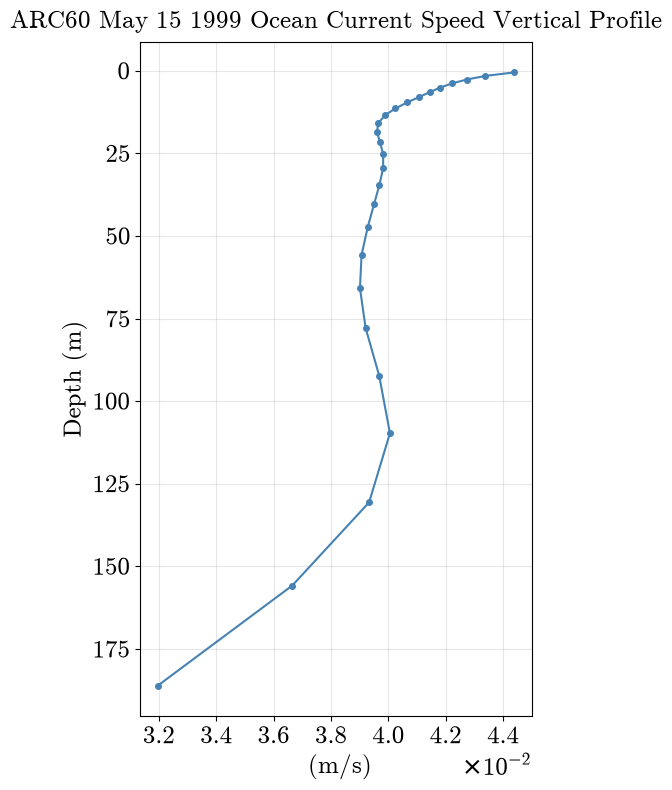

(<Figure size 500x800 with 1 Axes>,
 <Axes: title={'center': 'ARC60 May 15 1999 Ocean Current Speed Vertical Profile'}, xlabel=' (m/s)', ylabel='Depth (m)'>)

In [104]:
graphVerticalProfile('vprofile_speed_y1999m05d15')

Figure saved → ../figures/vertical_profiles/vprofile_speed_y1999m05d15.png


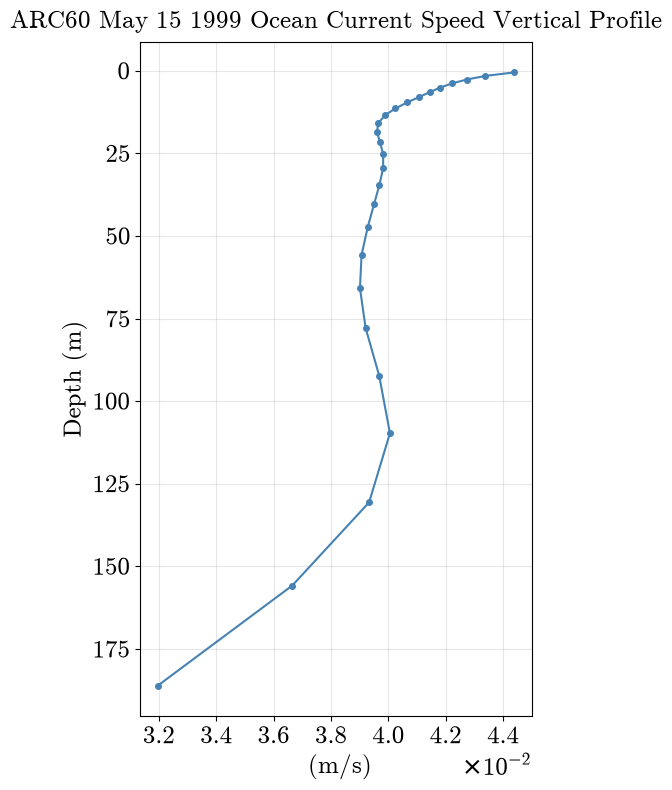

Figure saved → ../figures/vertical_profiles/vprofile_eke_y1999m05d15.png


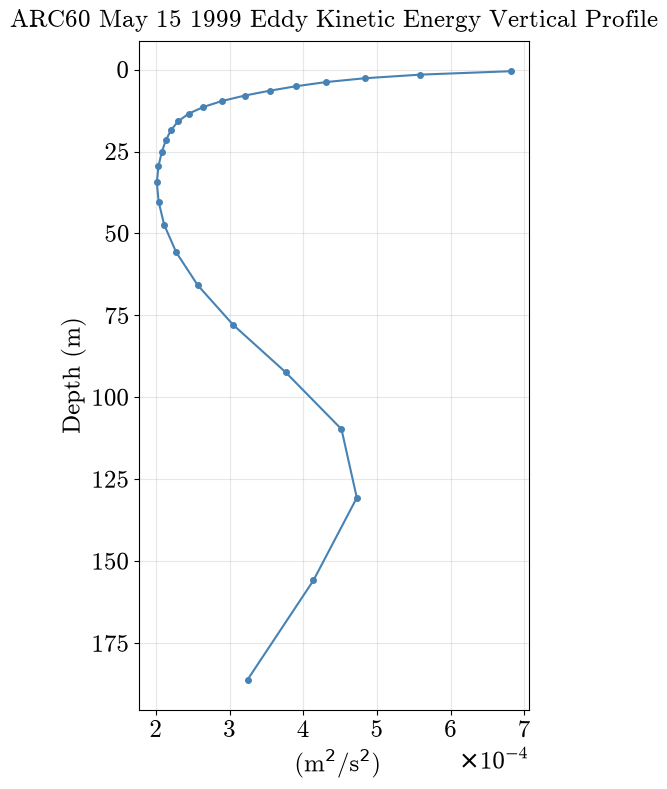

Figure saved → ../figures/vertical_profiles/vprofile_speed_y1999m06d01.png


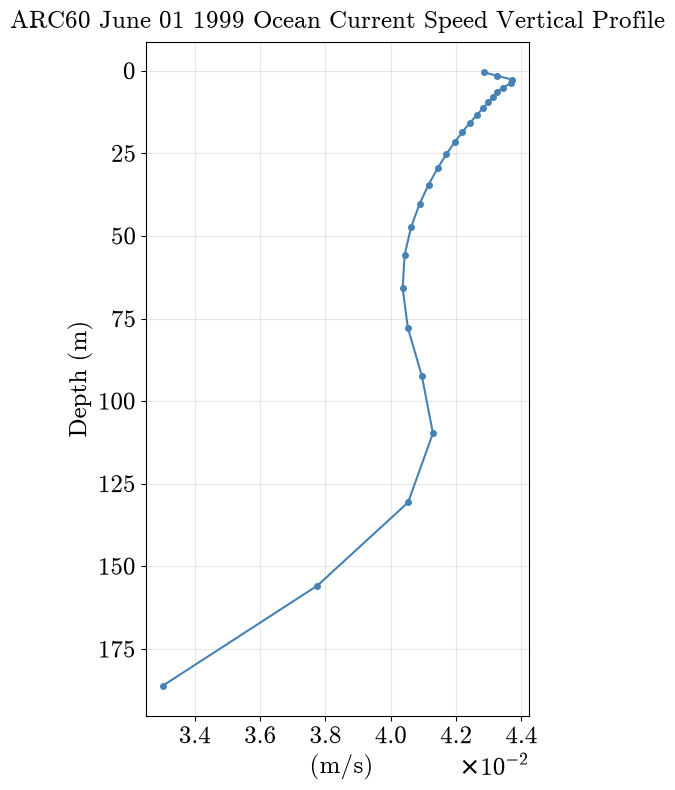

Figure saved → ../figures/vertical_profiles/vprofile_eke_y1999m06d01.png


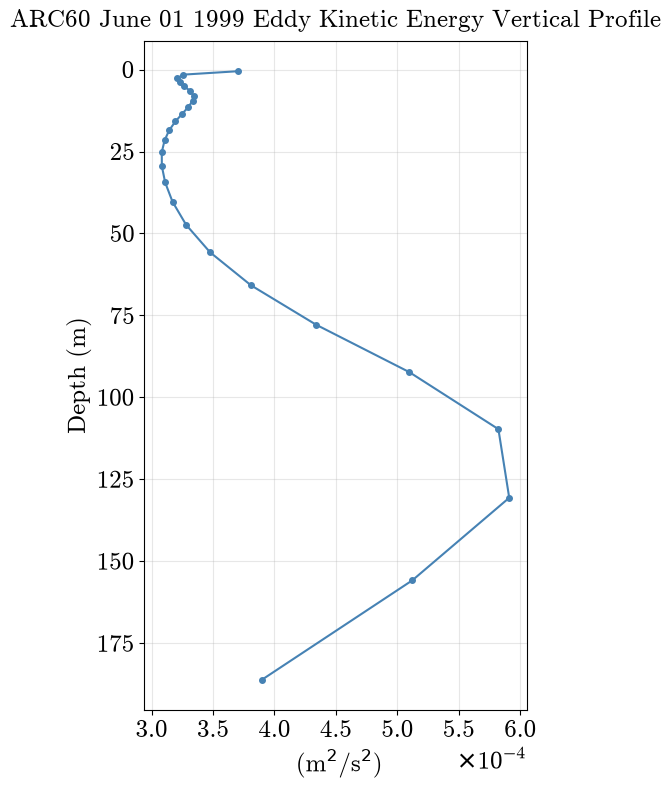

Figure saved → ../figures/vertical_profiles/vprofile_speed_y1999m06d15.png


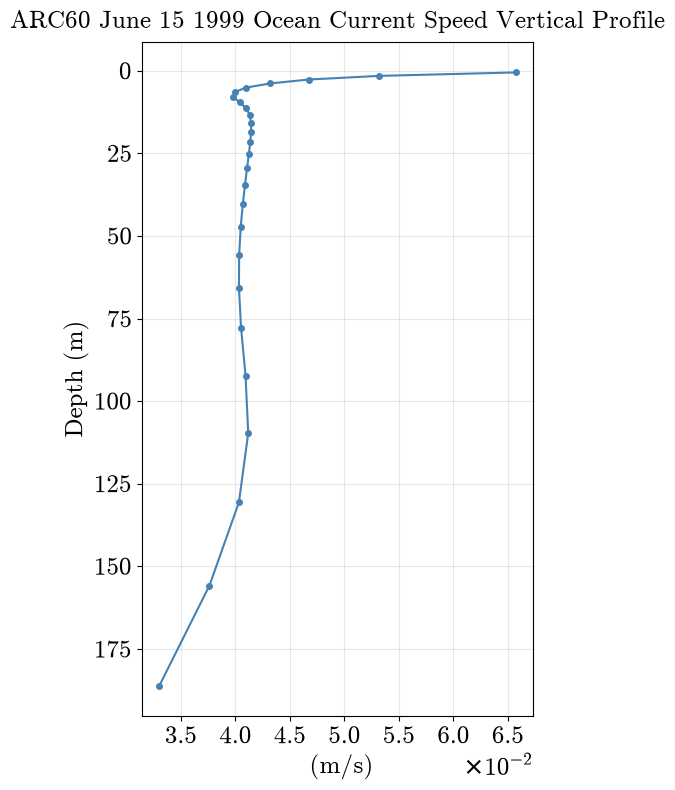

Figure saved → ../figures/vertical_profiles/vprofile_speed_y1999m06d15.png


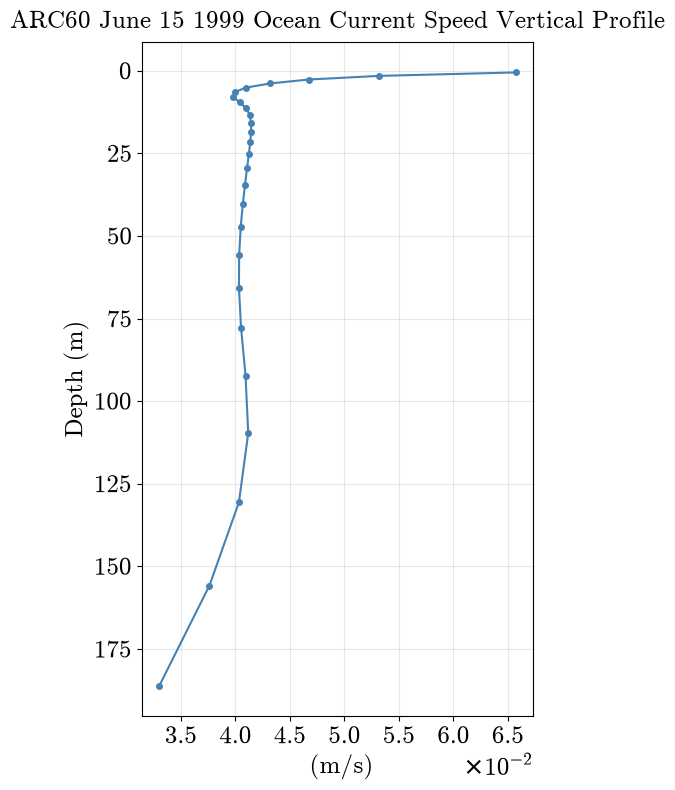

(<Figure size 500x800 with 1 Axes>,
 <Axes: title={'center': 'ARC60 June 15 1999 Ocean Current Speed Vertical Profile'}, xlabel=' (m/s)', ylabel='Depth (m)'>)

In [105]:
graphVerticalProfile('vprofile_speed_y1999m05d15', save=True)
graphVerticalProfile('vprofile_eke_y1999m05d15', save=True)
graphVerticalProfile('vprofile_speed_y1999m06d01', save=True)
graphVerticalProfile('vprofile_eke_y1999m06d01', save=True)
graphVerticalProfile('vprofile_speed_y1999m06d15', save=True)
graphVerticalProfile('vprofile_speed_y1999m06d15', save=True)